# Pilot Study — Mining-Layer Validation

A copy of `00_msr_validation` pointed at the pilot run (`Replication/PilotStudy`): four
repositories, each taken through the full experiment — the TestMap lane and the agentic
tools. The question is the same as the MSR pass: did TestMap record and attribute what the
underlying tools reported? It is asked here of databases that also hold every generated
attempt.

This notebook is diagnostic. Its job is to find weaknesses in the collected data before the
full evaluation run spends compute on them.

Two differences from the MSR corpus change how the numbers read:

- **Reports accumulate.** Each database holds one baseline test run, coverage report and
  mutation report, plus one of each per generated attempt. The structural checks run over
  every row; the distributions are scoped to the **baseline** report, so they describe the
  repository rather than how often it was re-measured.
- **Coverage misses are persisted.** The corrected coverage schema writes report entries the
  mapper could not place — a NULL entity plus an `attribution_status` — instead of logging
  and dropping them (bug 6 in `../msr_validation_bugs.md`). Coverage attribution is
  measurable from the database for the first time.

Experiment outcomes (lanes, tools, cost) belong to notebooks 01–05, run with
`ANALYSIS_DATA_DIR` pointed at `Replication/PilotStudy/evaluation`.

## Data Preparation

TestMap writes one SQLite database per repository revision. Consolidate the pilot's four
into per-construct frames:

```powershell
uv run python -m analysis build-msr-datasets `
  --db  "../Replication/PilotStudy/data/Output" `
  --out "../Replication/PilotStudy/msr"
```

There is no population-selection or coverage-audit step: the pilot targets were chosen by
hand (`pilot.yaml`), and coverage now carries its own attribution status.

Rows are keyed by `repo_key` (`owner/repo@commit12`); member ids are per-database
autoincrement values and collide across repositories, so every join must carry it.

In [1]:
import re
import sqlite3
from contextlib import closing
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from analysis.msr_stats import (
    NUMERIC_COLUMNS,
    describe_numeric,
    iqr_table,
    summarize_checks,
    worst_repositories,
)
from analysis import msr_plots

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")

PILOT      = Path("../../Replication/PilotStudy")
FRAMES     = PILOT / "msr" / "frames"
OUTPUT     = PILOT / "data" / "Output"
MSR_FRAMES = Path("../../Replication/MSRValidation/frames")

def load(name: str, frames: Path = FRAMES) -> pd.DataFrame:
    path = frames / f"msr_{name}.csv"
    if not path.exists():
        print(f"[missing] {path} - run build-msr-datasets first")
        return pd.DataFrame()
    return pd.read_csv(path, low_memory=False)

repositories = load("repositories")
files        = load("files")
entities     = load("entities")
code_metrics = load("code_metrics")
test_smells  = load("test_smells")
coverage     = load("coverage")
mutants      = load("mutants")
mutant_operators = load("mutant_operators")
mappings     = load("mappings")
test_results = load("test_results")
checks       = load("structural_checks")

CONSTRUCT_FRAMES = {
    "entities": entities,
    "code_metrics": code_metrics,
    "test_smells": test_smells,
    "coverage": coverage,
    "mutants": mutants,
    "mappings": mappings,
}

pd.DataFrame(
    [{"frame": n, "rows": len(f), "repos": f["repo_key"].nunique() if not f.empty else 0}
     for n, f in CONSTRUCT_FRAMES.items()]
)

,frame,rows,repos
0,entities,12336,4
1,code_metrics,12159,4
2,test_smells,3616,4
3,coverage,311455,4
4,mutants,57600,4
5,mappings,3860,4


## Pilot Targets And Pipeline Outcomes

The targets in `pilot.yaml`, their terminal state from `target-execution-*.csv`, and the
per-repository validation flags from `project-validation.csv`. With four targets the funnel
is a checklist rather than a rate, but the flags still have to agree with what the databases
hold: selection trusts the flags, so a flag that contradicts its database is a reporting bug
whichever side is right.

4 targets in pilot.yaml  ·  4 with an execution row


,repository,status,failure_stage,failure_kind,hours
0,dotnetcore/aspectcore-framework,Completed,NaN,NaN,42.66
1,cysharp/zstring,Completed,NaN,NaN,8.784
2,serilog/serilog-expressions,Completed,NaN,NaN,10.19
3,alirezanet/gridify,Completed,NaN,NaN,11


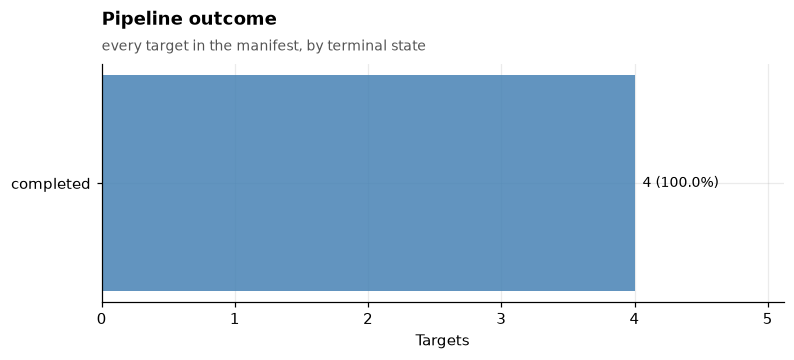

In [2]:
execution  = pd.read_csv(next(OUTPUT.glob("target-execution-*.csv")))
validation = pd.read_csv(OUTPUT / "project-validation.csv")
manifest_targets = re.findall(r"^ *repository: *(\S+)",
                              (PILOT / "pilot.yaml").read_text(encoding="utf-8"), re.M)

execution["hours"] = (
    pd.to_datetime(execution["completed_at_utc"]) - pd.to_datetime(execution["started_at_utc"])
).dt.total_seconds() / 3600
print(f"{len(manifest_targets)} targets in pilot.yaml  ·  {len(execution)} with an execution row")
display(execution[["repository", "status", "failure_stage", "failure_kind", "hours"]])

outcomes = (
    execution["status"].str.lower().value_counts()
    .rename_axis("outcome").rename("targets").reset_index()
    .assign(share=lambda d: d["targets"] / d["targets"].sum())
)
msr_plots.outcome_bar(outcomes)
plt.show()

In [3]:
CAPABILITIES = ["Restores", "Builds", "TestsRun", "TestsPass", "HasCoverage", "HasMutationScore"]

def _flag(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().eq("true")

capability = pd.DataFrame({
    "capability": CAPABILITIES,
    "repositories": [int(_flag(validation[c]).sum()) for c in CAPABILITIES],
    "denominator": len(validation),
}).assign(share=lambda d: d["repositories"] / d["denominator"])
display(capability)
display(validation[["Owner", "Repo", *CAPABILITIES, "CandidateCount",
                    "ExperimentEligibleCandidateCount", "CoverageStatus"]])

,capability,repositories,denominator,share
0,Restores,4,4,1
1,Builds,4,4,1
2,TestsRun,4,4,1
3,TestsPass,4,4,1
4,HasCoverage,4,4,1
5,HasMutationScore,3,4,0.75


,Owner,Repo,Restores,Builds,TestsRun,TestsPass,HasCoverage,HasMutationScore,CandidateCount,ExperimentEligibleCandidateCount,CoverageStatus
0,cysharp,zstring,True,True,True,True,True,True,262,28,PartiallyMapped
1,alirezanet,gridify,True,True,True,True,True,False,78,39,PartiallyMapped
2,serilog,serilog-expressions,True,True,True,True,True,True,137,49,PartiallyMapped
3,dotnetcore,aspectcore-framework,True,True,True,True,True,True,100,83,PartiallyMapped


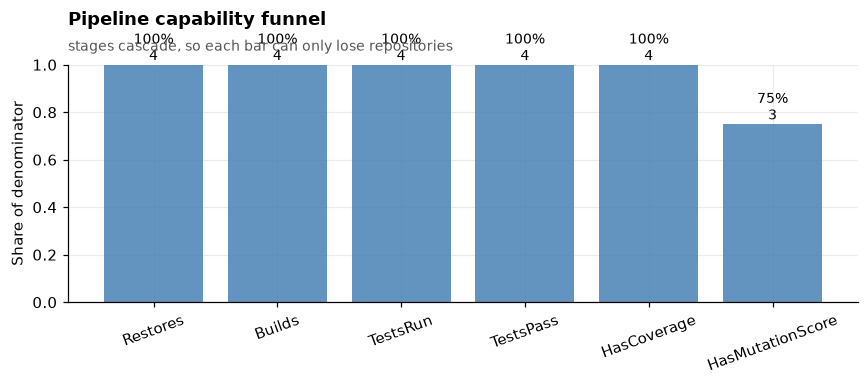

In [4]:
# Capability order is the cascade order, so the bars read as a funnel: each step
# can only lose repositories, and the size of a drop names the stage that costs most.
msr_plots.capability_funnel(capability)
plt.tight_layout()
plt.show()

In [5]:
# Flags against databases. HasCoverage / HasMutationScore come from the validation run;
# has_coverage / has_mutants from what the database actually holds.
flags = validation.assign(repo=lambda d: (d["Owner"] + "/" + d["Repo"]).str.lower())
held = repositories.assign(repo=lambda d: (d["owner"] + "/" + d["repo_name"]).str.lower())
compare = flags.merge(held, on="repo", how="outer", indicator=True).assign(
    coverage_flag=lambda d: _flag(d["HasCoverage"]),
    mutation_flag=lambda d: _flag(d["HasMutationScore"]),
)
display(compare[["repo", "_merge", "coverage_flag", "has_coverage", "coverage_reports",
                 "mutation_flag", "has_mutants", "mutation_reports"]])
for row in compare.itertuples():
    if row.coverage_flag != bool(row.has_coverage):
        print(f"[mismatch] {row.repo}: HasCoverage={row.coverage_flag} "
              f"but the database has_coverage={row.has_coverage}")
    if row.mutation_flag != bool(row.has_mutants):
        print(f"[mismatch] {row.repo}: HasMutationScore={row.mutation_flag} "
              f"but the database holds {row.mutation_reports} mutation report(s)")

# The validation run also reports how much of each baseline coverage report mapped.
display(validation.assign(
    member_mapped_share=lambda d: d["MappedCoverageMemberCount"] / d["RawCoverageMemberCount"],
    object_mapped_share=lambda d: d["MappedCoverageObjectCount"] / d["RawCoverageObjectCount"],
)[["Owner", "Repo", "CoverageStatus", "RawCoverageMemberCount", "MappedCoverageMemberCount",
   "member_mapped_share", "RawCoverageObjectCount", "MappedCoverageObjectCount",
   "object_mapped_share"]])

,repo,_merge,coverage_flag,has_coverage,coverage_reports,mutation_flag,has_mutants,mutation_reports
0,alirezanet/gridify,both,True,True,47,False,True,45
1,cysharp/zstring,both,True,True,43,True,True,43
2,dotnetcore/aspectcore-framework,both,True,True,61,True,True,58
3,serilog/serilog-expressions,both,True,True,45,True,True,43


[mismatch] alirezanet/gridify: HasMutationScore=False but the database holds 45 mutation report(s)


,Owner,Repo,CoverageStatus,RawCoverageMemberCount,MappedCoverageMemberCount,member_mapped_share,RawCoverageObjectCount,MappedCoverageObjectCount,object_mapped_share
0,cysharp,zstring,PartiallyMapped,955,421,0.4408,80,79,0.9875
1,alirezanet,gridify,PartiallyMapped,90243,1203,0.01333,5626,183,0.03253
2,serilog,serilog-expressions,PartiallyMapped,888,852,0.9595,160,160,1
3,dotnetcore,aspectcore-framework,PartiallyMapped,7535,5553,0.737,1225,1153,0.9412


## Baseline And Attempt Reports

Every attempt that ran its tests wrote a test run, a coverage report and a mutation report
into the same database as the baseline. The baseline is identified by run id for coverage
and test results (`baseline_*` against `iteration_*`). For mutation, `is_baseline` is not
enough on its own: the tool lane records a targeted baseline per attempt (`SourceProject`
scope, `is_baseline` = 1), so the repository baseline is the single `Solution`-scope one.
The `*_base` frames defined here are what the distribution sections use.

In [6]:
def query_db(row, sql: str) -> pd.DataFrame:
    path = (OUTPUT / row.owner / row.repo_name / row.commit_hash / "analysis.db").resolve()
    with closing(sqlite3.connect(f"{path.as_uri()}?mode=ro", uri=True)) as conn:
        return pd.read_sql_query(sql, conn).assign(repo_key=row.repo_key)

def per_repo(sql: str) -> pd.DataFrame:
    # A repository with no matching rows comes back as an all-object frame; dropping it
    # keeps the numeric columns numeric after the concat.
    frames = [query_db(r, sql) for r in repositories.itertuples()]
    frames = [f for f in frames if not f.empty] or frames[:1]
    return pd.concat(frames, ignore_index=True)

coverage_reports = (
    coverage.drop_duplicates(["repo_key", "coverage_report_id"])
    [["repo_key", "coverage_report_id", "coverage_run_id", "test_run_id",
      "raw_member_count", "mapped_member_count", "raw_object_count", "mapped_object_count"]]
    .assign(baseline=lambda d: d["coverage_run_id"].astype(str).str.startswith("baseline"))
)
mutation_reports = per_repo(
    "SELECT id AS mutation_testing_report_id, test_run_id, is_baseline, scope_kind "
    "FROM mutation_testing_reports"
)

base_cov = coverage_reports[coverage_reports["baseline"]]
base_mut = mutation_reports[(mutation_reports["is_baseline"] == 1)
                            & (mutation_reports["scope_kind"] == "Solution")]
coverage_base = coverage.merge(base_cov[["repo_key", "coverage_report_id"]],
                               on=["repo_key", "coverage_report_id"])
test_results_base = test_results.merge(base_cov[["repo_key", "test_run_id"]],
                                       on=["repo_key", "test_run_id"])
mutants_base = mutants.merge(base_mut[["repo_key", "mutation_testing_report_id"]],
                             on=["repo_key", "mutation_testing_report_id"])

display(pd.DataFrame({
    "coverage_reports": coverage_reports.groupby("repo_key").size(),
    "baseline_coverage": base_cov.groupby("repo_key").size(),
    "mutation_reports": mutation_reports.groupby("repo_key").size(),
    "baseline_mutation": base_mut.groupby("repo_key").size(),
    "test_runs": test_results.groupby("repo_key")["test_run_id"].nunique(),
    "baseline_test_results": test_results_base.groupby("repo_key").size(),
}).fillna(0).astype(int))

for name, frame in [("coverage", base_cov), ("mutation", base_mut)]:
    counts = frame.groupby("repo_key").size().reindex(repositories["repo_key"], fill_value=0)
    for repo_key, n in counts.items():
        if n != 1:
            print(f"[warn] {repo_key}: {n} baseline {name} report(s), expected exactly 1")

,coverage_reports,baseline_coverage,mutation_reports,baseline_mutation,test_runs,baseline_test_results
repo_key,,,,,,
alirezanet/gridify@2d6b9b3fe66f,46,1,45,0,46,1258
cysharp/zstring@e2b86f7ad433,43,1,43,1,43,147
dotnetcore/aspectcore-framework@d8fa5ca2d16c,58,1,58,1,58,6146
serilog/serilog-expressions@697c8fa89ec1,43,1,43,1,43,928


[warn] alirezanet/gridify@2d6b9b3fe66f: 0 baseline mutation report(s), expected exactly 1


## Study Population And Data Availability

Not every repository carries every construct. Static analysis runs on all of them,
but coverage and mutation only exist where the test suite built and ran, so the
denominators differ per construct. Everything downstream — sampling frames, rates,
per-construct budgets — depends on knowing these counts first.

,repositories,with_data,share
code_metrics,4,4,1
test_smells,4,4,1
coverage,4,4,1
mutants,4,4,1
mappings,4,4,1


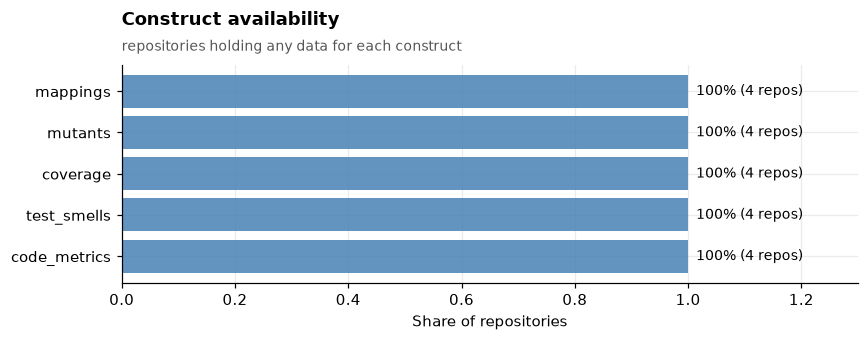

In [7]:
availability = pd.DataFrame({
    "repositories": [len(repositories)] * 5,
    "with_data": [
        int(repositories["has_metrics"].sum()),
        int(repositories["has_smells"].sum()),
        int(repositories["has_coverage"].sum()),
        int(repositories["has_mutants"].sum()),
        int(repositories["has_mappings"].sum()),
    ],
}, index=["code_metrics", "test_smells", "coverage", "mutants", "mappings"])
availability["share"] = availability["with_data"] / availability["repositories"]
display(availability)

msr_plots.availability_bar(availability)
plt.tight_layout()
plt.show()

In [8]:
# Reconcile availability against the frames themselves. A construct can be present
# in a repository yet absent from its frame when the frame's grain drops rows -
# msr_mutants is grouped per member, so a repository whose mutants are all
# unattributed produces no rows at all and disappears from it.
frame_repos = pd.DataFrame([
    {"frame": name,
     "repos_in_frame": f["repo_key"].nunique() if not f.empty else 0,
     "repos_with_data": int(repositories[flag].sum())}
    for name, f, flag in [
        ("code_metrics", code_metrics, "has_metrics"),
        ("test_smells", test_smells, "has_smells"),
        ("coverage", coverage, "has_coverage"),
        ("mutants (per member)", mutants, "has_mutants"),
        ("mutant_operators", mutant_operators, "has_mutants"),
        ("mappings", mappings, "has_mappings"),
        ("test_results", test_results, "has_test_results"),
    ]
]).assign(gap=lambda d: d["repos_with_data"] - d["repos_in_frame"])
display(frame_repos)

for row in frame_repos[frame_repos["gap"] > 0].itertuples():
    print(f"[gap] {row.frame}: {row.gap} repository(ies) hold data but contribute no rows")

,frame,repos_in_frame,repos_with_data,gap
0,code_metrics,4,4,0
1,test_smells,4,4,0
2,coverage,4,4,0
3,mutants (per member),4,4,0
4,mutant_operators,4,4,0
5,mappings,4,4,0
6,test_results,4,4,0


In [9]:
# Repositories where static analysis produced nothing at all: these are not a
# sampling population, they are a pipeline failure to account for separately.
empty = repositories[repositories["members"] == 0]
print(f"repositories with zero members: {len(empty)} of {len(repositories)}")

size_cols = ["files", "objects", "members", "test_members", "code_metrics",
             "test_smells", "coverage_rows", "mutants", "mappings"]
repositories[size_cols].sum().to_frame("corpus_total")

repositories with zero members: 0 of 4


,corpus_total
files,951
objects,2133
members,10203
test_members,3928
code_metrics,12159
test_smells,3616
coverage_rows,311455
mutants,1004630
mappings,3860


## Structural Checks

Each check is a rate with an explicit numerator and denominator, computed per
repository and pooled here. Three severities:

- **defect** — the row cannot be correct as stored (orphan foreign key, duplicate
  attribution, value out of range, a line outside its member's span);
- **coverage_gap** — the row is absent rather than wrong (a member with no metric
  row, a mutant with no member attribution);
- **suspect** — worth a look, not necessarily wrong.

Rates pool numerators and denominators across repositories rather than averaging
per-repo rates, so a large repository counts for more than a tiny one.

A repository that never collected a construct is excluded from that construct's gap
rate — that is an availability fact, recorded above, and folding it in here would
swamp the real missing-row rate.

Here the checks pool every report in each database — baseline and attempts alike — because
a defect in an attempt row is still a defect. The per-construct sections below say where a
figure is baseline-only.


,construct,check,severity,repositories,repositories_affected,numerator,denominator,rate
0,mutants,mutants_containment_violation,defect,4,4,3890,564700,0.006889
1,test_smells,smells_containment_violation,defect,4,3,8,3592,0.002227
14,mappings,production_members_missing_mappings,coverage_gap,4,4,3826,4148,0.9224
15,mutants,members_missing_mutants,coverage_gap,4,4,8350,10203,0.8184
16,mappings,test_members_missing_mappings,coverage_gap,4,4,2600,3928,0.6619
17,coverage,coverage_unattributed,coverage_gap,4,4,139528,311455,0.448
18,mutants,mutants_unattributed,coverage_gap,4,2,439930,1004630,0.4379
19,coverage,objects_missing_coverage,coverage_gap,4,4,647,2133,0.3033
20,coverage,members_missing_coverage,coverage_gap,4,4,2516,10203,0.2466
21,test_results,test_members_missing_results,coverage_gap,4,4,137,3928,0.03488


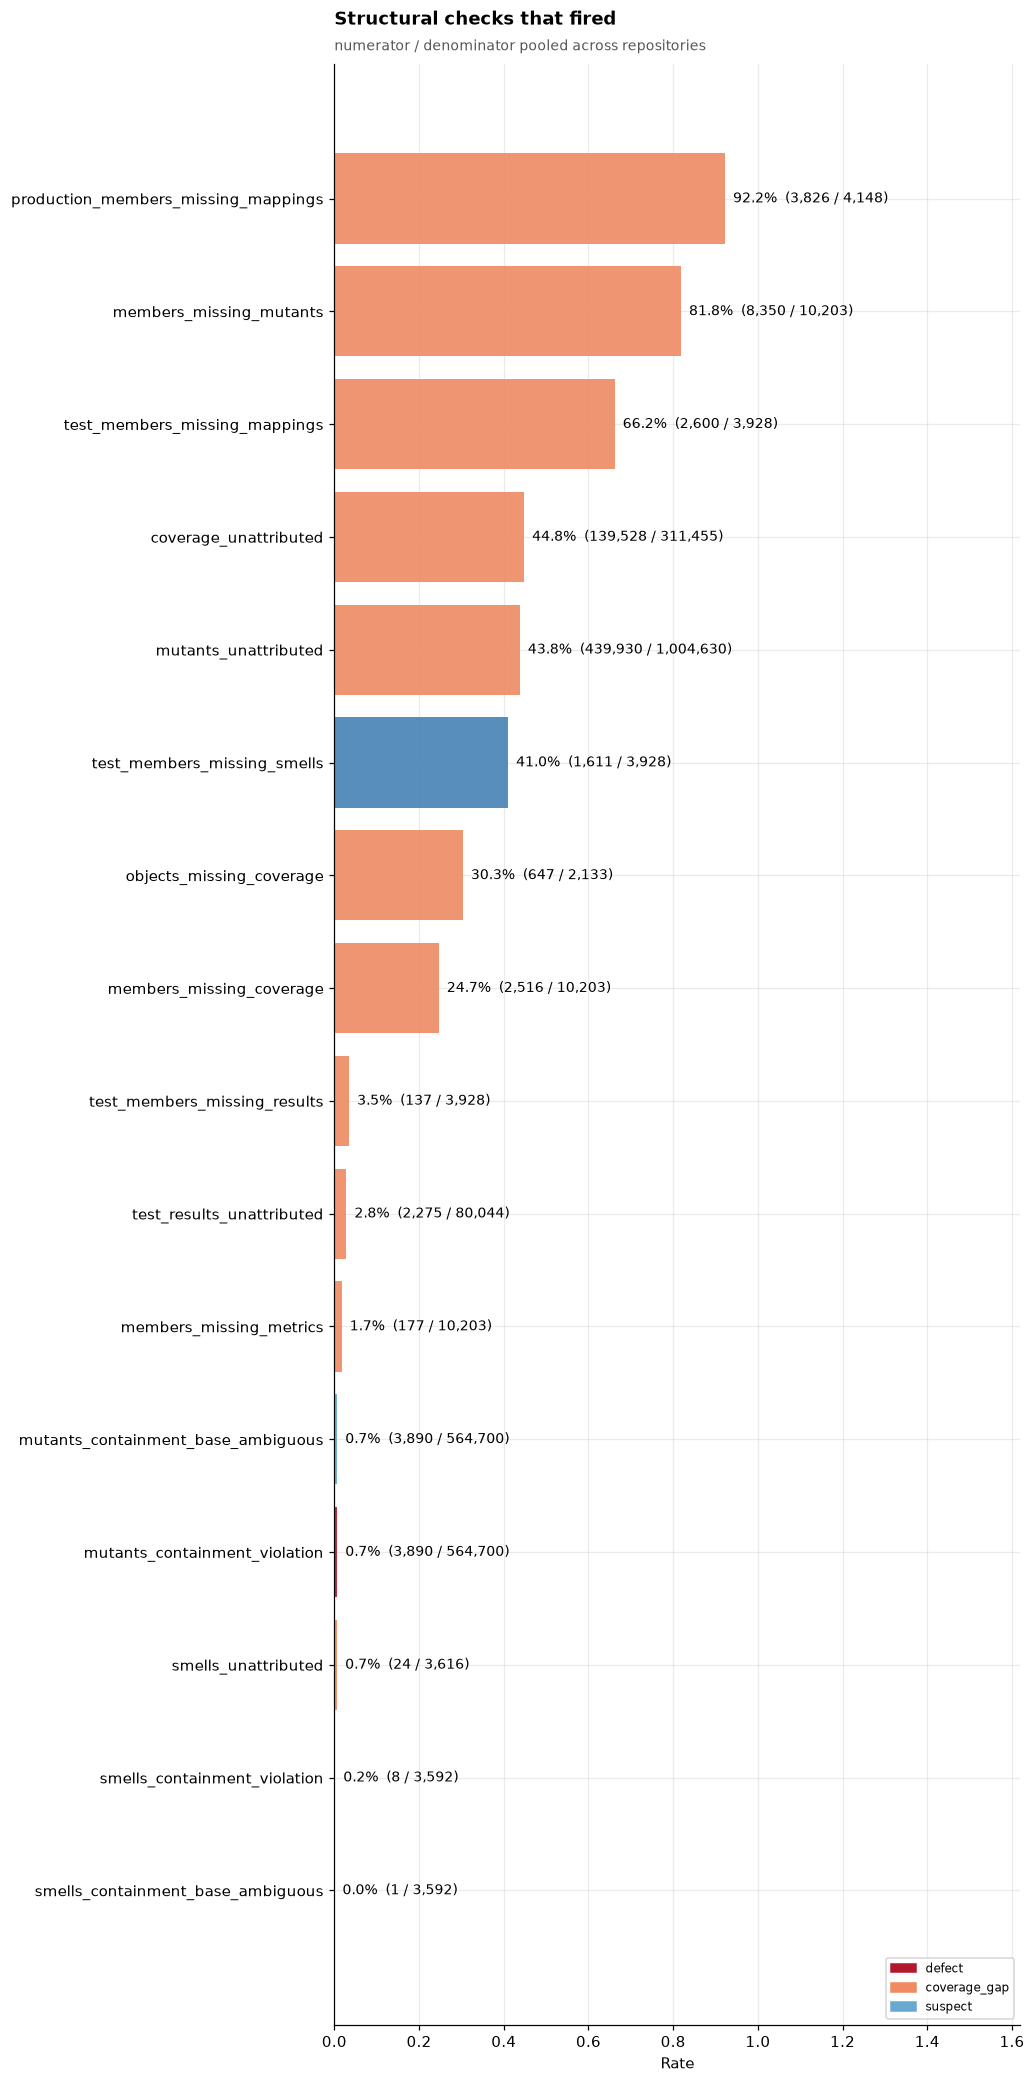

In [10]:
summary = summarize_checks(checks)
display(summary[summary["numerator"] > 0])

msr_plots.check_rate_bar(summary)
plt.tight_layout()
plt.show()

In [11]:
# Everything that came back clean. Worth reading: a check that is zero everywhere
# is either genuinely healthy or not actually exercised - confirm the denominator.
summary[summary["numerator"] == 0][["construct", "check", "denominator", "repositories"]]

,construct,check,denominator,repositories
2,code_metrics,metrics_duplicate_entity,12159,4
3,code_metrics,metrics_mi_out_of_range,12159,4
4,code_metrics,metrics_orphan_entity,12159,4
5,coverage,coverage_orphan_entity,311455,4
6,coverage,coverage_rate_inconsistent,311455,4
7,coverage,coverage_rate_out_of_range,311455,4
8,mappings,mappings_duplicate_pair,3860,4
9,mappings,mappings_orphan_source,3860,4
10,mappings,mappings_orphan_test,3860,4
11,mappings,mappings_self_reference,3860,4


### Per-repository breakdown

Corpus rates hide concentration. A 3% defect rate spread evenly across every
repository is a systematic fault in the extractor; the same 3% concentrated in two
repositories is a property of those repositories. The distinction decides whether to
fix code or to stratify the sample.

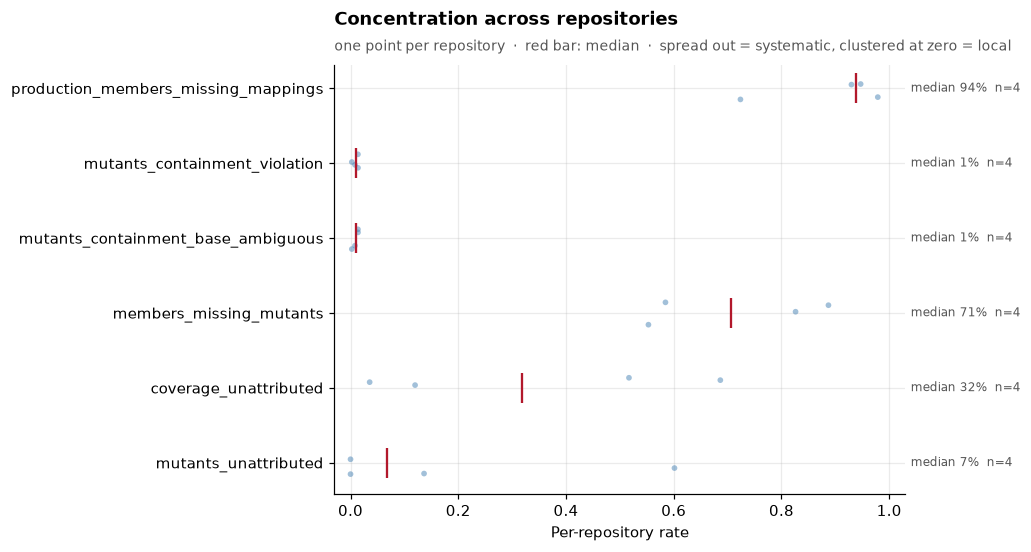

Top 5 repositories per missing-data check


,check,repo_key,numerator,denominator,rate
0,coverage_unattributed,alirezanet/gridify@2d6b9b3fe66f,106977,155826,0.6865
1,coverage_unattributed,cysharp/zstring@e2b86f7ad433,23005,44505,0.5169
2,coverage_unattributed,dotnetcore/aspectcore-framework@d8fa5ca2d16c,7958,66406,0.1198
3,coverage_unattributed,serilog/serilog-expressions@697c8fa89ec1,1588,44718,0.03551
4,members_missing_coverage,cysharp/zstring@e2b86f7ad433,500,821,0.609
5,members_missing_coverage,serilog/serilog-expressions@697c8fa89ec1,388,1103,0.3518
6,members_missing_coverage,alirezanet/gridify@2d6b9b3fe66f,295,1398,0.211
7,members_missing_coverage,dotnetcore/aspectcore-framework@d8fa5ca2d16c,1333,6881,0.1937
8,members_missing_metrics,cysharp/zstring@e2b86f7ad433,73,821,0.08892
9,members_missing_metrics,serilog/serilog-expressions@697c8fa89ec1,30,1103,0.0272


Top 5 repositories per defect check


,check,repo_key,numerator,denominator,rate
0,mutants_containment_violation,dotnetcore/aspectcore-framework@d8fa5ca2d16c,1135,81857,0.01387
1,mutants_containment_violation,alirezanet/gridify@2d6b9b3fe66f,1035,75375,0.01373
2,mutants_containment_violation,serilog/serilog-expressions@697c8fa89ec1,1032,124442,0.008293
3,mutants_containment_violation,cysharp/zstring@e2b86f7ad433,688,283026,0.002431
4,smells_containment_violation,cysharp/zstring@e2b86f7ad433,5,341,0.01466
5,smells_containment_violation,serilog/serilog-expressions@697c8fa89ec1,1,131,0.007634
6,smells_containment_violation,dotnetcore/aspectcore-framework@d8fa5ca2d16c,2,2288,0.0008741


,repos_affected,total,max_repo_rate
check,,,
mutants_unattributed,2,439930,0.6014
coverage_unattributed,4,139528,0.6865
members_missing_mutants,4,8350,0.8872
mutants_containment_base_ambiguous,4,3890,0.01387
mutants_containment_violation,4,3890,0.01387
production_members_missing_mappings,4,3826,0.9788
test_members_missing_mappings,4,2600,0.8673
members_missing_coverage,4,2516,0.609
test_results_unattributed,4,2275,0.04589


In [12]:
def check_by_repo(check_name: str, top_n: int = 15) -> pd.DataFrame:
    rows = worst_repositories(checks, check_name, top_n=top_n)
    if rows.empty:
        print(f"[none] {check_name}")
    return rows

top_checks = (
    checks[checks["numerator"] > 0]
    .groupby("check")["numerator"].sum()
    .nlargest(6).index.tolist()
)
msr_plots.per_repo_rate_strip(checks, top_checks)
plt.tight_layout()
plt.show()

# Which repositories carry each gap. Ranked per check so a bad repository is
# named rather than left inside a pooled rate; ties on rate break on volume.
TOP_N = 5

def rank_repositories(severity: str, top_n: int = TOP_N) -> pd.DataFrame:
    subset = checks[(checks["severity"] == severity) & (checks["numerator"] > 0)]
    if subset.empty:
        return pd.DataFrame()
    return (
        subset.sort_values(["check", "rate", "numerator"], ascending=[True, False, False])
        .groupby("check", group_keys=False)
        .head(top_n)
        .loc[:, ["check", "repo_key", "numerator", "denominator", "rate"]]
        .reset_index(drop=True)
    )

print(f"Top {TOP_N} repositories per missing-data check")
display(rank_repositories("coverage_gap"))

print(f"Top {TOP_N} repositories per defect check")
display(rank_repositories("defect"))

affected = (
    checks[checks["numerator"] > 0]
    .groupby("check")
    .agg(repos_affected=("repo_key", "nunique"),
         total=("numerator", "sum"),
         max_repo_rate=("rate", "max"))
    .sort_values("total", ascending=False)
)
affected

## Code Metrics

TestMap collects code metrics through a custom library built on the Roslyn API,
persisted to `code_metrics` with an `entity_type` of `member` or `object`.

Aggregates are split by entity type: a class and a method are not the same
measurement, and pooling them makes both distributions unreadable.

In [13]:
# Shared for the four construct sections below.
#   attribution_summary - how many observations resolve to a code entity
#   rank_unattributed   - which repositories carry the failures
TOP_N_REPOS = 10

def attribution_summary(check_name: str, construct: str) -> pd.DataFrame:
    rows = checks[checks["check"] == check_name]
    if rows.empty:
        return pd.DataFrame()
    missing = int(rows["numerator"].sum())
    total = int(rows["denominator"].sum())
    return pd.DataFrame([{
        "construct": construct,
        "observations": total,
        "attributed": total - missing,
        "missing_attribution": missing,
        "attributed_pct": (total - missing) / total if total else float("nan"),
    }])

def entity_gap_summary(check_name: str, entity: str) -> pd.DataFrame:
    # The complement of attribution: attribution asks whether an emitted row
    # points at a real entity, this asks how many entities never got a row.
    rows = checks[checks["check"] == check_name]
    if rows.empty:
        return pd.DataFrame()
    missing = int(rows["numerator"].sum())
    total = int(rows["denominator"].sum())
    return pd.DataFrame([{
        "entity": entity,
        "entities": total,
        "with_row": total - missing,
        "no_row": missing,
        "with_row_pct": (total - missing) / total if total else float("nan"),
        "repositories_affected": int((rows["numerator"] > 0).sum()),
    }])


def rank_unattributed(check_name: str, top_n: int = TOP_N_REPOS) -> pd.DataFrame:
    rows = checks[(checks["check"] == check_name) & (checks["numerator"] > 0)]
    if rows.empty:
        print(f"[none] no repository fired {check_name}")
        return pd.DataFrame()
    return (
        rows.sort_values(["rate", "numerator"], ascending=False)
        .head(top_n)
        .loc[:, ["repo_key", "numerator", "denominator", "rate"]]
        .reset_index(drop=True)
    )

=== code_metrics / member (10,026 rows) ===


,column,count,missing,min,max,mean,median,std
0,maintainability_index,10026,0,20,100,82.47,82,14.49
1,cyclomatic_complexity,10026,0,0,54,1.424,1,2.29
2,class_coupling,10026,0,0,46,4.553,3,4.74
3,depth_of_inheritance,10026,0,0,0,0,0,0
4,source_lines_of_code,10026,0,1,269,8.545,6,12.72
5,executable_lines_of_code,10026,0,0,158,4.031,3,5.72


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,maintainability_index,10026,71,82,100,29,27.5,143.5,3,0,0.0002992
1,cyclomatic_complexity,10026,1,1,1,0,1,1,1103,1926,0.3021
2,class_coupling,10026,1,3,7,6,-8,16,0,268,0.02673
3,depth_of_inheritance,10026,0,0,0,0,0,0,0,0,0
4,source_lines_of_code,10026,1,6,11,10,-14,26,0,402,0.0401
5,executable_lines_of_code,10026,1,3,6,5,-6.5,13.5,0,327,0.03262


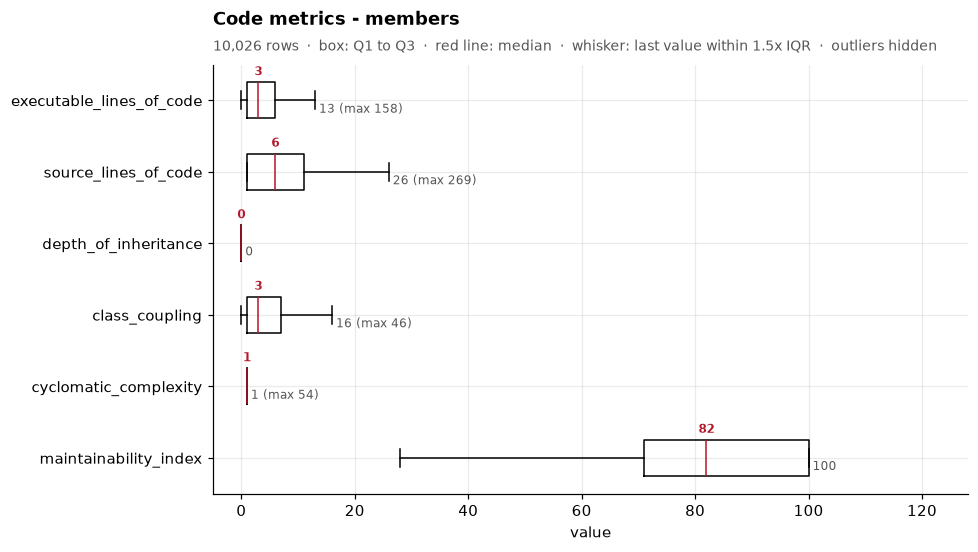

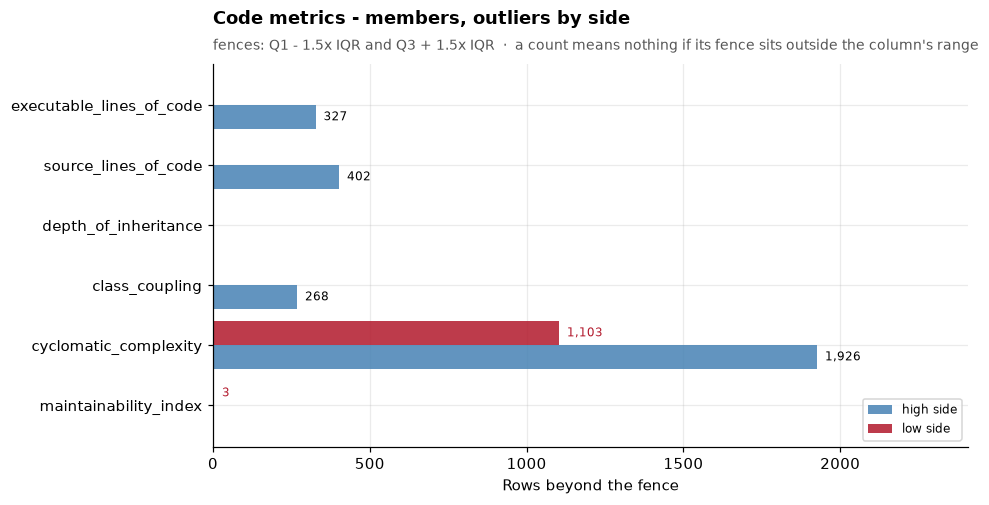

=== code_metrics / object (2,133 rows) ===


,column,count,missing,min,max,mean,median,std
0,maintainability_index,2133,0,22,100,86.83,93,13.83
1,cyclomatic_complexity,2133,0,0,1058,7.93,2,40.71
2,class_coupling,2133,0,0,86,6.21,3,8.727
3,depth_of_inheritance,2133,0,0,6,1.15,1,0.7577
4,source_lines_of_code,2133,0,1,8213,54.98,10,268.1
5,executable_lines_of_code,2133,0,0,2075,19.65,2,87.89


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,maintainability_index,2133,75,93,100,25,37.5,137.5,1,0,0.0004688
1,cyclomatic_complexity,2133,1,2,6,5,-6.5,13.5,0,211,0.09892
2,class_coupling,2133,1,3,8,7,-9.5,18.5,0,181,0.08486
3,depth_of_inheritance,2133,1,1,1,0,1,1,287,449,0.3451
4,source_lines_of_code,2133,5,10,35,30,-40,80,0,303,0.1421
5,executable_lines_of_code,2133,1,2,12,11,-15.5,28.5,0,306,0.1435


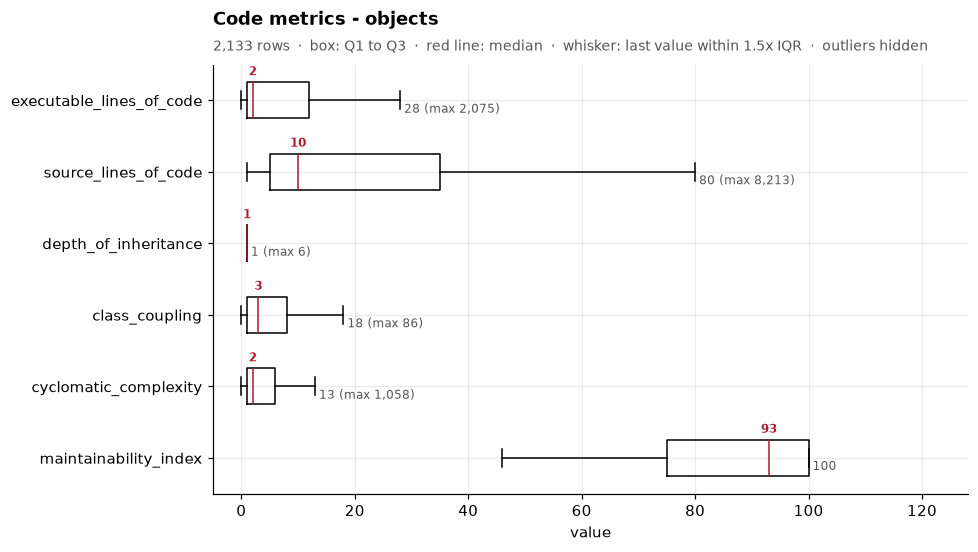

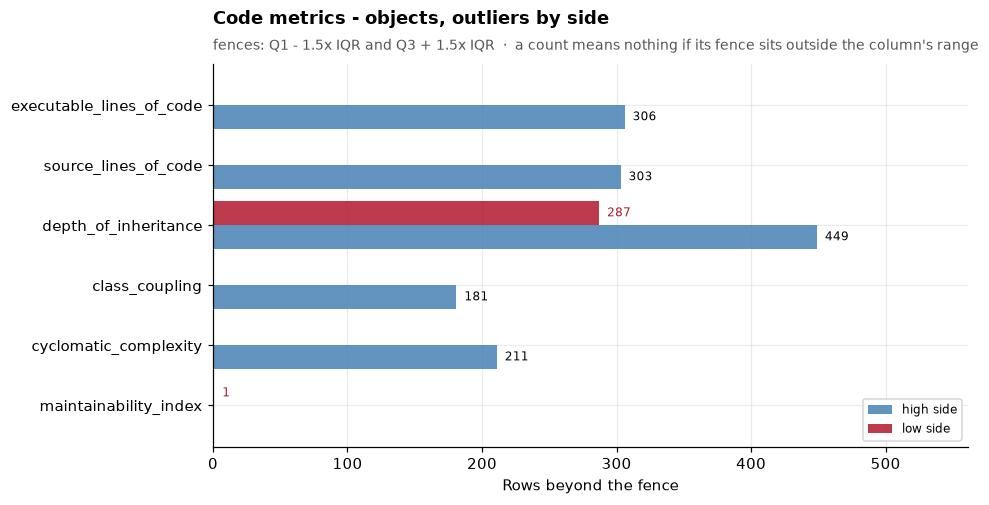

In [14]:
METRIC_COLS = NUMERIC_COLUMNS["code_metrics"]

for kind in ["member", "object"]:
    subset = code_metrics[code_metrics["entity_kind"] == kind]
    if subset.empty:
        continue
    print(f"=== code_metrics / {kind} ({len(subset):,} rows) ===")
    display(describe_numeric(subset, METRIC_COLS))
    display(iqr_table(subset, METRIC_COLS))
    msr_plots.distribution_box(subset, METRIC_COLS,
                               title=f"Code metrics - {kind}s")
    plt.tight_layout()
    plt.show()
    msr_plots.outlier_bar(iqr_table(subset, METRIC_COLS),
                          title=f"Code metrics - {kind}s, outliers by side")
    plt.tight_layout()
    plt.show()

In [15]:
# Attribution: a metric row points at an entity_id that must exist. Missing
# attribution here means the row survived but its entity did not.
#
# Same caveat as coverage below: this detects dangling references, not entries the
# mapper skipped. Members that never received a metric row are the complementary
# measure, ranked second.
display(attribution_summary("metrics_orphan_entity", "code_metrics"))
print("repositories ranked by metric rows pointing at a missing entity")
display(rank_unattributed("metrics_orphan_entity"))

# The complement, for both entity kinds: how many members and objects never
# received a metric row at all.
print("entities carrying no metric row")
display(pd.concat([
    entity_gap_summary("members_missing_metrics", "member"),
    entity_gap_summary("objects_missing_metrics", "object"),
], ignore_index=True))

print("repositories ranked by members carrying no metric row")
display(rank_unattributed("members_missing_metrics"))
print("repositories ranked by objects carrying no metric row")
display(rank_unattributed("objects_missing_metrics"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,code_metrics,12159,12159,0,1


repositories ranked by metric rows pointing at a missing entity
[none] no repository fired metrics_orphan_entity


""


entities carrying no metric row


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,member,10203,10026,177,0.9827,4
1,object,2133,2133,0,1,0


repositories ranked by members carrying no metric row


,repo_key,numerator,denominator,rate
0,cysharp/zstring@e2b86f7ad433,73,821,0.08892
1,serilog/serilog-expressions@697c8fa89ec1,30,1103,0.0272
2,alirezanet/gridify@2d6b9b3fe66f,22,1398,0.01574
3,dotnetcore/aspectcore-framework@d8fa5ca2d16c,52,6881,0.007557


repositories ranked by objects carrying no metric row
[none] no repository fired objects_missing_metrics


""


## Test Smells

Smells come from an xNose-based detector. `TestSmellService` attributes each finding
to a member by file path plus nearest start line, breaking ties on the newest member
id — so stale member rows left by earlier generated attempts can win, and that is the
risk stratum for the manual attribution sheet.

The aggregate is per smell type, measured as findings per repository: the corpus
total says which smells are common, the spread says whether that is a few
repositories or all of them.

,smell_name,column,count,missing,min,max,mean,median,std
0,Assertion Roulette Test Smell,findings,3,0,22,274,165,199,129.4
1,Conditional Test Smell,findings,4,0,4,36,13.5,7,15.15
2,Duplicate Assertion Test Smell,findings,4,0,20,357,158.2,128,142
3,Eager Test Smell,findings,4,0,25,1147,437.5,289,496.7
4,Equal In Assert Test Smell,findings,2,0,11,14,12.5,12.5,2.121
5,Lack of Cohesion of Test Cases,findings,4,0,1,13,5.25,3.5,5.315
6,Magic Number Test Smell,findings,4,0,2,412,123.8,40.5,194.1
7,Obscure Inline Setup Test Smell,findings,4,0,1,6,2.5,1.5,2.38
8,Redundant Assertion Test Smell,findings,1,0,12,12,12,12,NaN
9,Redundant Print Test Smell,findings,1,0,3,3,3,3,NaN


,smell_name,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,Assertion Roulette Test Smell,findings,3,110.5,199,236.5,126,-78.5,425.5,0,0,0
1,Conditional Test Smell,findings,4,4.75,7,15.75,11,-11.75,32.25,0,1,0.25
2,Duplicate Assertion Test Smell,findings,4,98.75,128,187.5,88.75,-34.38,320.6,0,1,0.25
3,Eager Test Smell,findings,4,143.5,289,583,439.5,-515.8,"1,242",0,0,0
4,Equal In Assert Test Smell,findings,2,11.75,12.5,13.25,1.5,9.5,15.5,0,0,0
5,Lack of Cohesion of Test Cases,findings,4,2.5,3.5,6.25,3.75,-3.125,11.88,0,1,0.25
6,Magic Number Test Smell,findings,4,12.5,40.5,151.8,139.2,-196.4,360.6,0,1,0.25
7,Obscure Inline Setup Test Smell,findings,4,1,1.5,3,2,-2,6,0,0,0
8,Redundant Assertion Test Smell,findings,1,12,12,12,0,12,12,0,0,0
9,Redundant Print Test Smell,findings,1,3,3,3,0,3,3,0,0,0


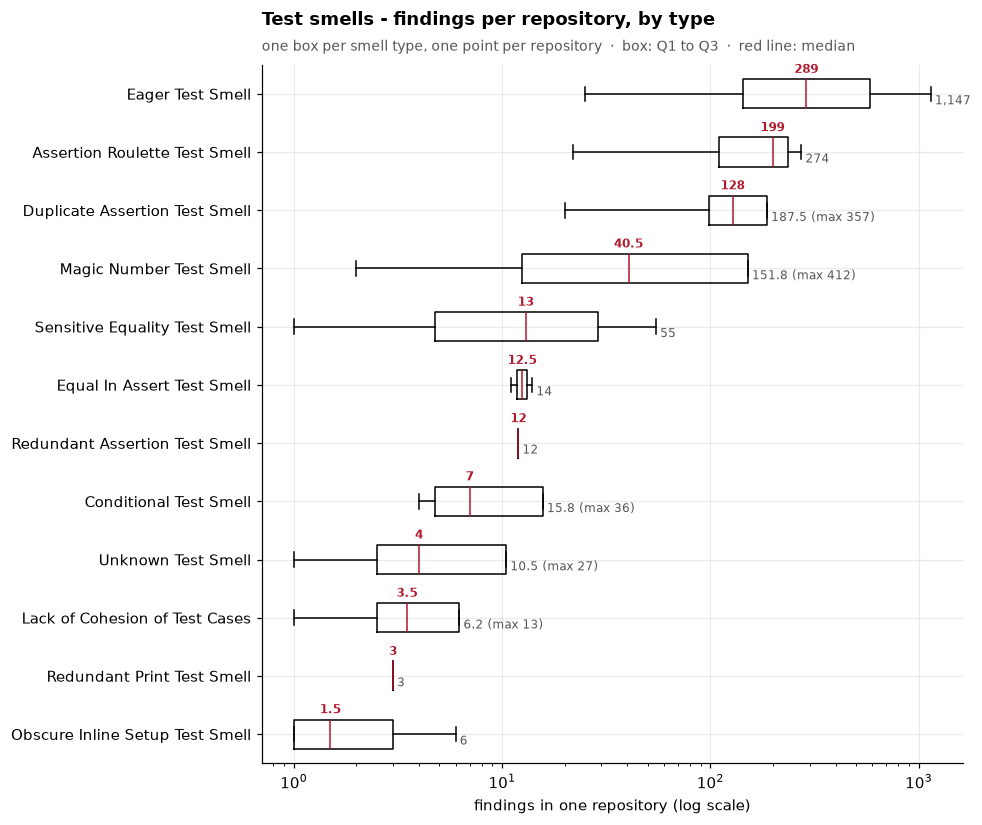

In [16]:
if not test_smells.empty:
    per_repo_type = (
        test_smells.groupby(["repo_key", "smell_name"])
        .size().rename("findings").reset_index()
    )
    display(describe_numeric(per_repo_type, ["findings"], by="smell_name"))
    display(iqr_table(per_repo_type, ["findings"], by="smell_name"))
    msr_plots.grouped_box(per_repo_type, "findings", "smell_name",
                          title="Test smells - findings per repository, by type",
                          subtitle="one box per smell type, one point per repository  ·  "
                                   "box: Q1 to Q3  ·  red line: median",
                          xlabel="findings in one repository")
    plt.tight_layout()
    plt.show()

,findings,share_of_all,repositories
smell_name,,,
Eager Test Smell,1750,0.484,4
Duplicate Assertion Test Smell,633,0.1751,4
Assertion Roulette Test Smell,495,0.1369,3
Magic Number Test Smell,495,0.1369,4
Sensitive Equality Test Smell,82,0.02268,4
Conditional Test Smell,54,0.01493,4
Unknown Test Smell,36,0.009956,4
Equal In Assert Test Smell,25,0.006914,2
Lack of Cohesion of Test Cases,21,0.005808,4


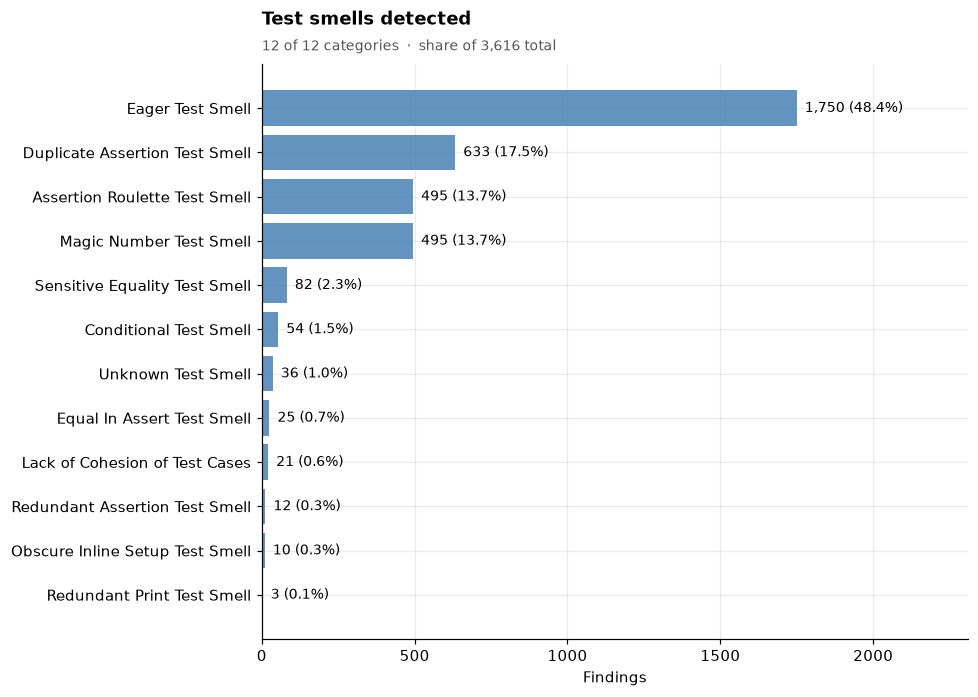

In [17]:
# Distribution across types: what share of all findings each smell accounts for.
if not test_smells.empty:
    smell_dist = (
        test_smells["smell_name"].value_counts().rename("findings").to_frame()
        .assign(share_of_all=lambda d: d["findings"] / d["findings"].sum(),
                repositories=lambda d: test_smells.groupby("smell_name")["repo_key"]
                                                  .nunique().reindex(d.index))
    )
    display(smell_dist)
    msr_plots.category_bar(test_smells["smell_name"].value_counts(),
                           "Test smells detected", "Findings", top_n=25)
    plt.tight_layout()
    plt.show()

In [18]:
# Attribution: member_id and object_id are both nullable, so a finding can land
# on no entity at all.
display(attribution_summary("smells_unattributed", "test_smells"))
print("repositories ranked by unattributed smell rate")
display(rank_unattributed("smells_unattributed"))

# The entity side of the same question. Read this one as prevalence, not as a
# gap: a test method with no smell is a clean test method, so `no_row` here is a
# property of the corpus rather than a failure of the detector. It is reported so
# every construct has both a linkage and an attribution figure.
print("test members carrying at least one smell")
display(entity_gap_summary("test_members_missing_smells", "test member"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,test_smells,3616,3592,24,0.9934


repositories ranked by unattributed smell rate


,repo_key,numerator,denominator,rate
0,cysharp/zstring@e2b86f7ad433,4,345,0.01159
1,serilog/serilog-expressions@697c8fa89ec1,1,132,0.007576
2,dotnetcore/aspectcore-framework@d8fa5ca2d16c,16,2304,0.006944
3,alirezanet/gridify@2d6b9b3fe66f,3,835,0.003593


test members carrying at least one smell


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,test member,3928,2317,1611,0.5899,4


In [19]:
# The attribution risk named above is live in these databases: attempts persisted
# generated test members next to the originals. Findings landing on them are counted
# separately, so they can be checked against the attempt that produced the member.
gen_members = entities[(entities["entity_kind"] == "member") & (entities["is_generated"] == 1)]
attributed_smells = test_smells.dropna(subset=["member_id"]).astype({"member_id": int})
on_generated = attributed_smells.merge(
    gen_members[["repo_key", "entity_id"]],
    left_on=["repo_key", "member_id"], right_on=["repo_key", "entity_id"],
)
print(f"generated members: {len(gen_members):,}  ·  "
      f"smell findings on them: {len(on_generated):,} of {len(attributed_smells):,} attributed")
if not on_generated.empty:
    display(on_generated.groupby(["repo_key", "smell_name"]).size().rename("findings").to_frame())

generated members: 36  ·  smell findings on them: 61 of 3,592 attributed


findings
repo_key                                     smell_name                               
alirezanet/gridify@2d6b9b3fe66f              Assertion Roulette Test Smell           6
                                             Duplicate Assertion Test Smell          6
                                             Eager Test Smell                        8
cysharp/zstring@e2b86f7ad433                 Duplicate Assertion Test Smell          6
                                             Eager Test Smell                        7
                                             Obscure Inline Setup Test Smell         1
dotnetcore/aspectcore-framework@d8fa5ca2d16c Assertion Roulette Test Smell           4
                                             Eager Test Smell                       13
serilog/serilog-expressions@697c8fa89ec1     Assertion Roulette Test Smell           4
                                             Duplicate Assertion Test Smell          1
                                             Eager Test Smell                        2
                                             Obscure Inline Setup Test Smell         1
                                             Sensitive Equality Test Smell           2

## Code Coverage

Coverage is parsed from Cobertura reports produced by `dotnet test` and mapped onto members
and objects. As in the MSR pass, **the coverage report is not under validation**: rates are
taken as recorded, and what is validated is attribution.

Two things are new in these databases. The per-entity count columns are persisted
(`line_counts_available`), so the counts-missing check should now read zero. And report
entries the mapper cannot place are written with a NULL entity and an
`attribution_status` — `Mapped`, `Unmatched`, `Ambiguous`, `Unsupported`, `ParentUnmatched`,
`OutOfProject` — so the miss rate the MSR pass could only estimate from logs is a count here.

Not every unplaced entry is a miss. Reports include assemblies outside the analysed project
(test projects, shared libraries, dependencies). An entry whose owning class or file lies
outside the persisted project is out of scope, not a mapping failure, and the tables keep
the two apart.

Distributions are over the baseline report only.

,column,count,missing,min,max,mean,median,std
0,line_rate,9604,0,0,1,0.794,1,0.3895
1,branch_rate,9604,0,0,1,0.9638,1,0.1809


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,line_rate,9604,0.9091,1,1,0.09091,0.7727,1.136,2065,0,0.215
1,branch_rate,9604,1,1,1,0,1,1,426,0,0.04436


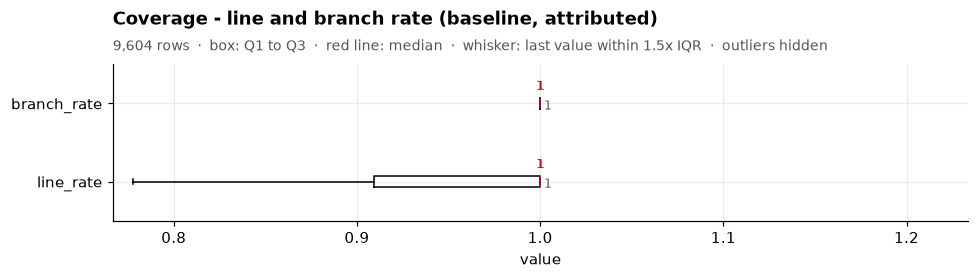

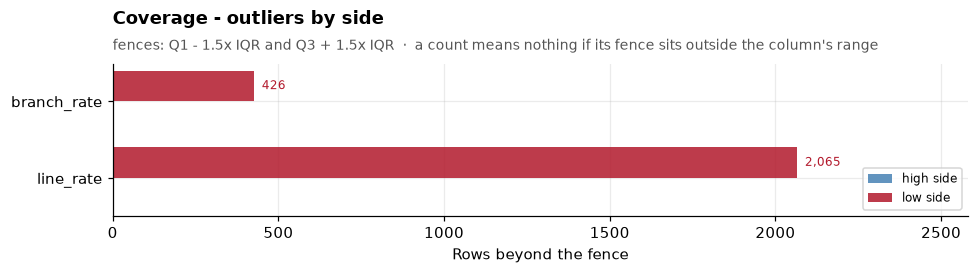

by entity type


,entity_kind,column,count,missing,min,max,mean,median,std
0,member,line_rate,8029,0,0,1,0.8177,1,0.376
1,member,branch_rate,8029,0,0,1,0.9682,1,0.1717
2,object,line_rate,1575,0,0,1,0.6734,0.9667,0.4329
3,object,branch_rate,1575,0,0,1,0.9412,1,0.2208


,entity_kind,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,member,line_rate,8029,1,1,1,0,1,1,1866,0,0.2324
1,member,branch_rate,8029,1,1,1,0,1,1,286,0,0.03562
2,object,line_rate,1575,0,0.9667,1,1,-1.5,2.5,0,0,0
3,object,branch_rate,1575,1,1,1,0,1,1,140,0,0.08889


In [20]:
COVERAGE_COLS = ["line_rate", "branch_rate"]
attributed_base = coverage_base[coverage_base["entity_id"].notna()]

if not attributed_base.empty:
    display(describe_numeric(attributed_base, COVERAGE_COLS))
    display(iqr_table(attributed_base, COVERAGE_COLS))
    msr_plots.distribution_box(attributed_base, COVERAGE_COLS, log=False,
                               title="Coverage - line and branch rate (baseline, attributed)")
    plt.tight_layout()
    plt.show()
    msr_plots.outlier_bar(iqr_table(attributed_base, COVERAGE_COLS),
                          title="Coverage - outliers by side")
    plt.tight_layout()
    plt.show()

    print("by entity type")
    display(describe_numeric(attributed_base, COVERAGE_COLS, by="entity_kind"))
    display(iqr_table(attributed_base, COVERAGE_COLS, by="entity_kind"))

In [21]:
# Attribution. coverage_unattributed counts persisted rows with no entity (every report);
# coverage_orphan_entity counts rows naming an entity that does not exist.
display(pd.concat([
    attribution_summary("coverage_unattributed", "coverage (unattributed)"),
    attribution_summary("coverage_orphan_entity", "coverage (orphan entity)"),
], ignore_index=True))

OUT_OF_PROJECT_REASONS = (
    "Owning coverage class is outside the persisted project.",
    "Coverage filename does not match a persisted project file.",
)

def coverage_bucket(frame: pd.DataFrame) -> pd.Series:
    return np.select(
        [frame["attribution_status"].eq("Mapped"),
         frame["attribution_reason"].isin(OUT_OF_PROJECT_REASONS)],
        ["mapped", "out_of_project"], default="in_project_miss",
    )

base_buckets = coverage_base.assign(bucket=coverage_bucket(coverage_base))
per_repo_cov = (
    base_buckets.pivot_table(index=["repo_key", "entity_kind"], columns="bucket",
                             values="observation_id", aggfunc="count", fill_value=0)
    .reindex(columns=["mapped", "in_project_miss", "out_of_project"], fill_value=0)
)
per_repo_cov["in_project_mapped_rate"] = (
    per_repo_cov["mapped"] / (per_repo_cov["mapped"] + per_repo_cov["in_project_miss"])
)
per_repo_cov["out_of_project_share"] = per_repo_cov["out_of_project"] / per_repo_cov[
    ["mapped", "in_project_miss", "out_of_project"]].sum(axis=1)
print("baseline report: where each coverage entry went")
display(per_repo_cov)

print("unplaced baseline entries, by status and reason")
display(
    coverage_base[coverage_base["attribution_status"].ne("Mapped")]
    .groupby(["entity_kind", "attribution_status", "attribution_reason"])
    .size().rename("rows").to_frame()
)

print("entities carrying no coverage row (any report)")
display(pd.concat([
    entity_gap_summary("members_missing_coverage", "member"),
    entity_gap_summary("objects_missing_coverage", "object"),
], ignore_index=True))
print("repositories ranked by members carrying no coverage row")
display(rank_unattributed("members_missing_coverage"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,coverage (unattributed),311455,171927,139528,0.552
1,coverage (orphan entity),311455,311455,0,1


baseline report: where each coverage entry went


bucket                                                    mapped  in_project_miss  out_of_project  in_project_mapped_rate  out_of_project_share
repo_key                                     entity_kind                                                                                       
alirezanet/gridify@2d6b9b3fe66f              member         1203              328           88712                  0.7858                 0.983
                                             object          183                6            5437                  0.9683                0.9664
cysharp/zstring@e2b86f7ad433                 member          421              534               0                  0.4408                     0
                                             object           79                1               0                  0.9875                     0
dotnetcore/aspectcore-framework@d8fa5ca2d16c member         5553             1772             210                  0.7581               0.02787
                                             object         1153               28              44                  0.9763               0.03592
serilog/serilog-expressions@697c8fa89ec1     member          852               36               0                  0.9595                     0
                                             object          160                0               0                       1                     0

unplaced baseline entries, by status and reason


rows
entity_kind attribution_status attribution_reason                                       
member      Ambiguous          Multiple persisted members remain after line an...      2
            ParentUnmatched    Owning coverage class attribution is ambiguous.       104
                               Owning coverage class is outside the persisted ...  88922
            Unmatched          No compatible persisted member matched the cove...   2472
            Unsupported        Coverage member name is compiler-generated or e...     92
object      Ambiguous          Multiple persisted code objects have the same b...     35
            OutOfProject       Coverage filename does not match a persisted pr...   5481

entities carrying no coverage row (any report)


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,member,10203,7687,2516,0.7534,4
1,object,2133,1486,647,0.6967,4


repositories ranked by members carrying no coverage row


,repo_key,numerator,denominator,rate
0,cysharp/zstring@e2b86f7ad433,500,821,0.609
1,serilog/serilog-expressions@697c8fa89ec1,388,1103,0.3518
2,alirezanet/gridify@2d6b9b3fe66f,295,1398,0.211
3,dotnetcore/aspectcore-framework@d8fa5ca2d16c,1333,6881,0.1937


In [22]:
# Bug 6 regression check: counts are persisted now, so both should read [none].
print("coverage rows with a rate but no counts")
display(check_by_repo("coverage_counts_missing_with_rate"))
print("coverage rows where lines_valid is zero")
display(check_by_repo("coverage_lines_valid_zero"))

coverage rows with a rate but no counts


,repo_key,check,numerator,denominator,rate
0,alirezanet/gridify@2d6b9b3fe66f,coverage_counts_missing_with_rate,0,155826,0
1,cysharp/zstring@e2b86f7ad433,coverage_counts_missing_with_rate,0,44505,0
2,dotnetcore/aspectcore-framework@d8fa5ca2d16c,coverage_counts_missing_with_rate,0,66406,0
3,serilog/serilog-expressions@697c8fa89ec1,coverage_counts_missing_with_rate,0,44718,0


coverage rows where lines_valid is zero


,repo_key,check,numerator,denominator,rate
0,alirezanet/gridify@2d6b9b3fe66f,coverage_lines_valid_zero,0,155826,0
1,cysharp/zstring@e2b86f7ad433,coverage_lines_valid_zero,0,44505,0
2,dotnetcore/aspectcore-framework@d8fa5ca2d16c,coverage_lines_valid_zero,0,66406,0
3,serilog/serilog-expressions@697c8fa89ec1,coverage_lines_valid_zero,0,44718,0


In [23]:
# Scope: does each attempt measure coverage over the same assemblies as the baseline?
# Deltas between an attempt and the baseline are only meaningful if it does.
scope = (
    coverage_reports.assign(report=lambda d: np.where(d["baseline"], "baseline", "attempt"))
    .groupby(["repo_key", "report"])
    .agg(reports=("coverage_report_id", "size"),
         raw_members=("raw_member_count", "median"),
         mapped_members=("mapped_member_count", "median"),
         raw_objects=("raw_object_count", "median"),
         mapped_objects=("mapped_object_count", "median"))
)
display(scope)
ratio = (scope.xs("attempt", level="report")["raw_members"]
         / scope.xs("baseline", level="report")["raw_members"])
for repo_key, value in ratio.items():
    if abs(value - 1) > 0.05:
        print(f"[scope] {repo_key}: attempt reports offer {value:.1%} of the baseline's raw members")

reports  raw_members  mapped_members  raw_objects  mapped_objects
repo_key                                     report                                                                     
alirezanet/gridify@2d6b9b3fe66f              attempt        45        1,181             908          149             146
                                             baseline        1    9.024e+04           1,203        5,626             183
cysharp/zstring@e2b86f7ad433                 attempt        42          955             421           80              79
                                             baseline        1          955             421           80              79
dotnetcore/aspectcore-framework@d8fa5ca2d16c attempt        57          911             807           97              97
                                             baseline        1        7,535           5,553        1,225           1,153
serilog/serilog-expressions@697c8fa89ec1     attempt        42          880             844          157             157
                                             baseline        1          888             852          160             160

[scope] alirezanet/gridify@2d6b9b3fe66f: attempt reports offer 1.3% of the baseline's raw members
[scope] dotnetcore/aspectcore-framework@d8fa5ca2d16c: attempt reports offer 12.1% of the baseline's raw members


## Mutation Score

Mutants come from Stryker.NET and are mapped to members. Each attempt re-runs Stryker, so a
database holds a mutation report per attempt on top of the baseline. The per-member
aggregate and the status tables here are scoped to the repository baseline report
(`is_baseline` = 1 and `scope_kind` = `Solution`); the structural checks above pool every report.

The per-member frame only holds mutants attached to a member. Status shares are taken over
every baseline mutant, attributed or not, queried from the databases directly — the
consolidated operator frame is not split by report. `mutants_containment_violation` counts
mutants whose line falls outside the member they were attributed to; where it equals
`mutants_containment_base_ambiguous`, every violation is a one-line boundary case.

,column,count,missing,min,max,mean,median,std
0,mutants_total,1605,0,1,372,8.997,4,20.5
1,killed,1605,0,0,166,2.717,1,6.33
2,survived,1605,0,0,24,0.6754,0,2.023
3,nocoverage,1605,0,0,273,2.725,0,11.67
4,compileerror,1605,0,0,48,0.8804,0,3.799
5,ignored,1605,0,0,67,1.941,1,4.702
6,timeout,1605,0,0,7,0.05857,0,0.3999
7,static_mutants,1605,0,0,47,0.481,0,2.574
8,distinct_mutators,1605,0,1,15,3.174,3,2.181


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,mutants_total,1605,1,4,9,8,-11,21,0,130,0.081
1,killed,1605,0,1,3,3,-4.5,7.5,0,133,0.08287
2,survived,1605,0,0,1,1,-1.5,2.5,0,111,0.06916
3,nocoverage,1605,0,0,1,1,-1.5,2.5,0,281,0.1751
4,compileerror,1605,0,0,0,0,0,0,0,302,0.1882
5,ignored,1605,0,1,2,2,-3,5,0,90,0.05607
6,timeout,1605,0,0,0,0,0,0,0,51,0.03178
7,static_mutants,1605,0,0,0,0,0,0,0,173,0.1078
8,distinct_mutators,1605,1,3,4,3,-3.5,8.5,0,46,0.02866


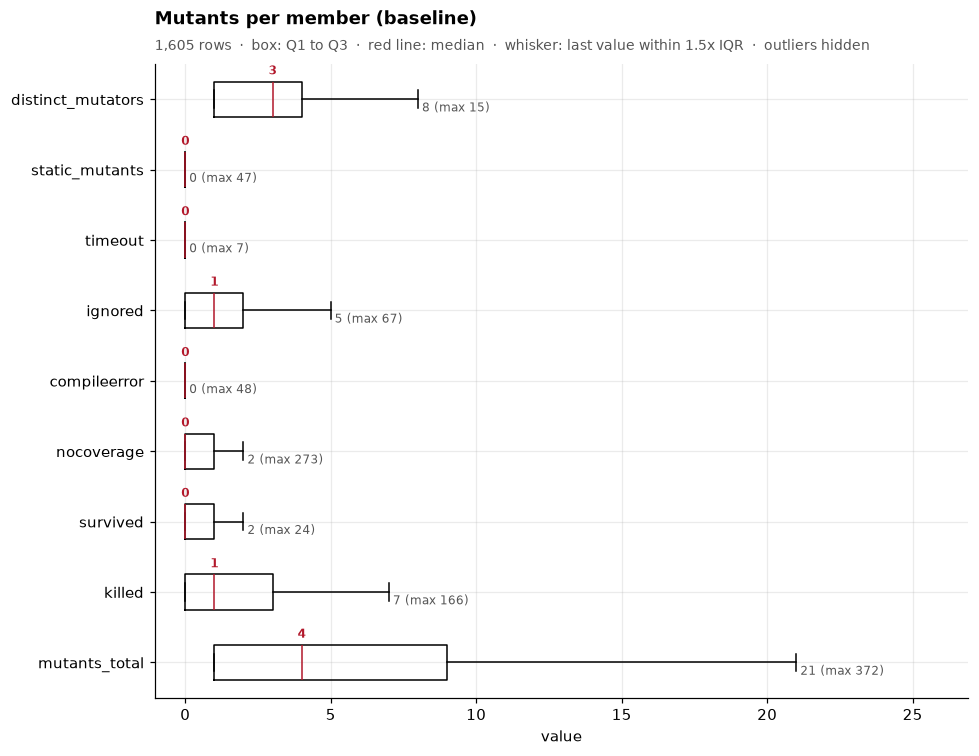

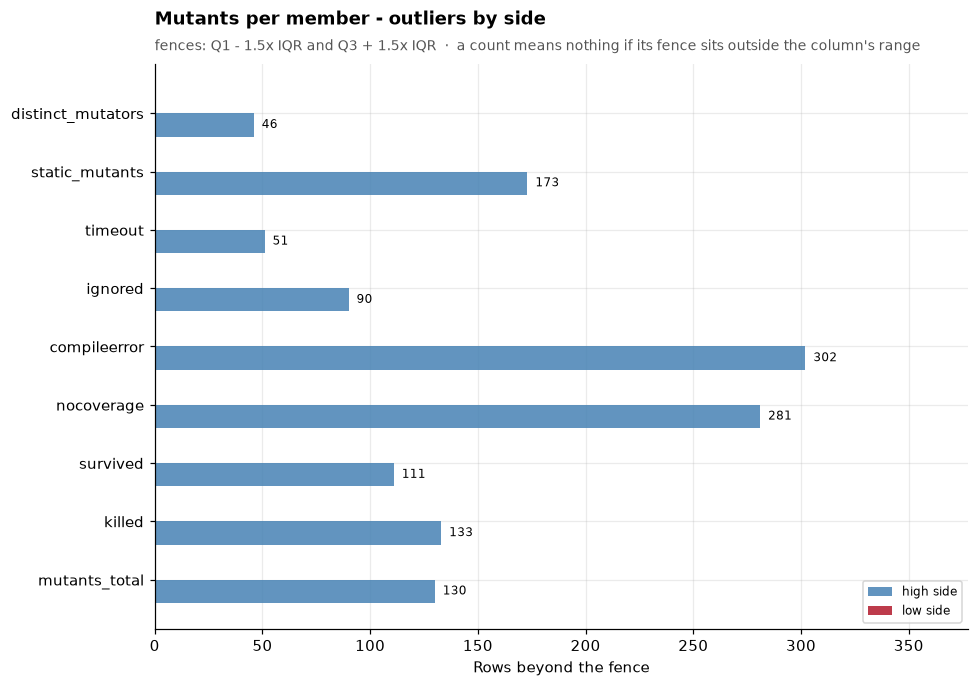

In [24]:
MUTANT_COLS = NUMERIC_COLUMNS["mutants"]

if not mutants_base.empty:
    display(describe_numeric(mutants_base, MUTANT_COLS))
    display(iqr_table(mutants_base, MUTANT_COLS))
    msr_plots.distribution_box(mutants_base, MUTANT_COLS, log=False,
                               title="Mutants per member (baseline)")
    plt.tight_layout()
    plt.show()
    msr_plots.outlier_bar(iqr_table(mutants_base, MUTANT_COLS),
                          title="Mutants per member - outliers by side")
    plt.tight_layout()
    plt.show()

[no baseline mutation] alirezanet/gridify@2d6b9b3fe66f: only attempt-level mutation reports exist


,mutants,share_of_all
status,,
NoCoverage,9800,0.3984
Killed,5085,0.2067
Ignored,4873,0.1981
CompileError,3372,0.1371
Survived,1367,0.05557
Timeout,102,0.004147


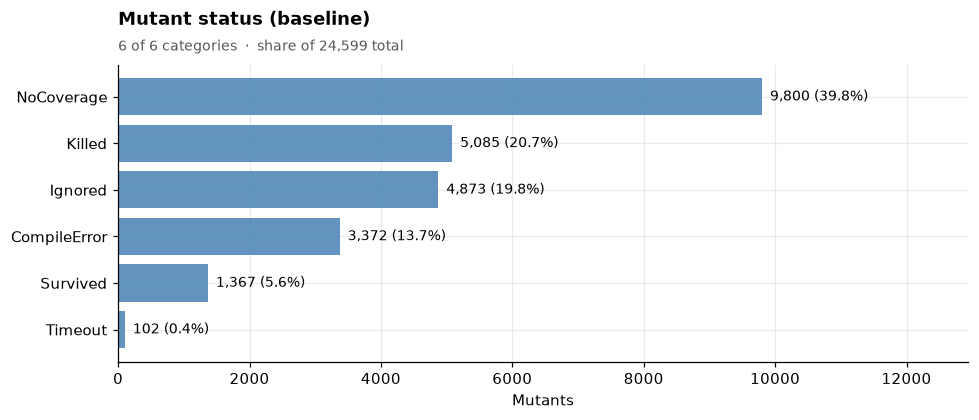

baseline mutants: 24,599
scored (Killed + Survived): 6,452 (26.2%)
attributed to a member: 14,440 (58.7%)


In [25]:
BASELINE_OPERATORS_SQL = """
    SELECT m.mutator_name, m.status, COUNT(*) AS mutants,
           SUM(CASE WHEN m.member_id IS NULL THEN 1 ELSE 0 END) AS unattributed
    FROM mutants m
    JOIN mutation_testing_reports r ON r.id = m.mutation_testing_report_id
    WHERE r.is_baseline = 1 AND r.scope_kind = 'Solution'
    GROUP BY m.mutator_name, m.status
"""
operators_base = per_repo(BASELINE_OPERATORS_SQL)
missing_baseline = sorted(set(repositories["repo_key"]) - set(operators_base["repo_key"]))
for repo_key in missing_baseline:
    print(f"[no baseline mutation] {repo_key}: only attempt-level mutation reports exist")
family = mutant_operators.drop_duplicates("mutator_name").set_index("mutator_name")["mutator_family"]
operators_base["mutator_family"] = operators_base["mutator_name"].map(family)

if not operators_base.empty:
    status_dist = (
        operators_base.groupby("status")["mutants"].sum().rename("mutants").to_frame()
        .assign(share_of_all=lambda d: d["mutants"] / d["mutants"].sum())
        .sort_values("mutants", ascending=False)
    )
    display(status_dist)
    msr_plots.category_bar(status_dist["mutants"], "Mutant status (baseline)", "Mutants")
    plt.tight_layout()
    plt.show()

    total = int(status_dist["mutants"].sum())
    scored = int(status_dist.reindex(["Killed", "Survived"], fill_value=0)["mutants"].sum())
    unattributed = int(operators_base["unattributed"].sum())
    print(f"baseline mutants: {total:,}")
    print(f"scored (Killed + Survived): {scored:,} ({scored / total:.1%})")
    print(f"attributed to a member: {total - unattributed:,} ({(total - unattributed) / total:.1%})")
    status_cols = ["killed", "survived", "nocoverage", "compileerror", "ignored", "timeout"]
    in_frame = int(mutants_base[status_cols].sum().sum())
    if in_frame != total - unattributed:
        print(f"[mismatch] per-member frame holds {in_frame:,} baseline mutants, "
              f"database says {total - unattributed:,} are attributed")

### Mutant status by operator

The same statuses split by which mutation operator produced the mutant. Operators
differ in how often they are killed, and in how often they are never reached at
all — a `NoCoverage` share says the operator fired in code no test touches, while a
`CompileError` share says the rewrite did not compile, which is a property of the
operator rather than of the test suite.

Stryker names Linq operators per rewrite (`Linq method mutation (Count() to Sum())`),
so the family view collapses that long tail; the exact-name table keeps it.

In [26]:
STATUS_ORDER = ["Killed", "Survived", "NoCoverage", "CompileError", "Ignored", "Timeout"]

if not operators_base.empty:
    by_family = (
        operators_base.pivot_table(index="mutator_family", columns="status",
                                     values="mutants", aggfunc="sum", fill_value=0)
        .reindex(columns=STATUS_ORDER, fill_value=0)
    )
    by_family["total"] = by_family.sum(axis=1)
    by_family["share_of_all"] = by_family["total"] / by_family["total"].sum()
    scored = by_family["Killed"] + by_family["Survived"]
    by_family["kill_rate"] = (by_family["Killed"] / scored).where(scored > 0)
    by_family = by_family.sort_values("total", ascending=False)
    display(by_family)

status,Killed,Survived,NoCoverage,CompileError,Ignored,Timeout,total,share_of_all,kill_rate
mutator_family,,,,,,,,,
Block removal mutation,402,67,280,298,4873,11,5931,0.2411,0.8571
Statement mutation,1224,294,3079,300,0,22,4919,0.2,0.8063
Equality mutation,1321,201,2574,671,0,14,4781,0.1944,0.8679
Arithmetic mutation,185,56,1187,127,0,5,1560,0.06342,0.7676
Negate expression,464,59,582,232,0,18,1355,0.05508,0.8872
Linq method mutation,58,45,40,814,0,1,958,0.03894,0.5631
String mutation,245,276,271,26,0,1,819,0.03329,0.4702
Logical mutation,179,88,284,197,0,7,755,0.03069,0.6704
Boolean mutation,297,84,295,55,0,5,736,0.02992,0.7795


status,Killed,Survived,NoCoverage,CompileError,Ignored,Timeout
mutator_family,,,,,,
PostIncrementExpression to PostDecrementExpression mutation,0.295,0.012,0.468,0.216,0,0.01
LogicalNotExpression to un-LogicalNotExpression mutation,0.415,0.073,0.417,0.081,0,0.014
Bitwise mutation,0.11,0.041,0.441,0.403,0,0.003
Boolean mutation,0.404,0.114,0.401,0.075,0,0.007
Logical mutation,0.237,0.117,0.376,0.261,0,0.009
String mutation,0.299,0.337,0.331,0.032,0,0.001
Linq method mutation,0.061,0.047,0.042,0.85,0,0.001
Negate expression,0.342,0.044,0.43,0.171,0,0.013
Arithmetic mutation,0.119,0.036,0.761,0.081,0,0.003


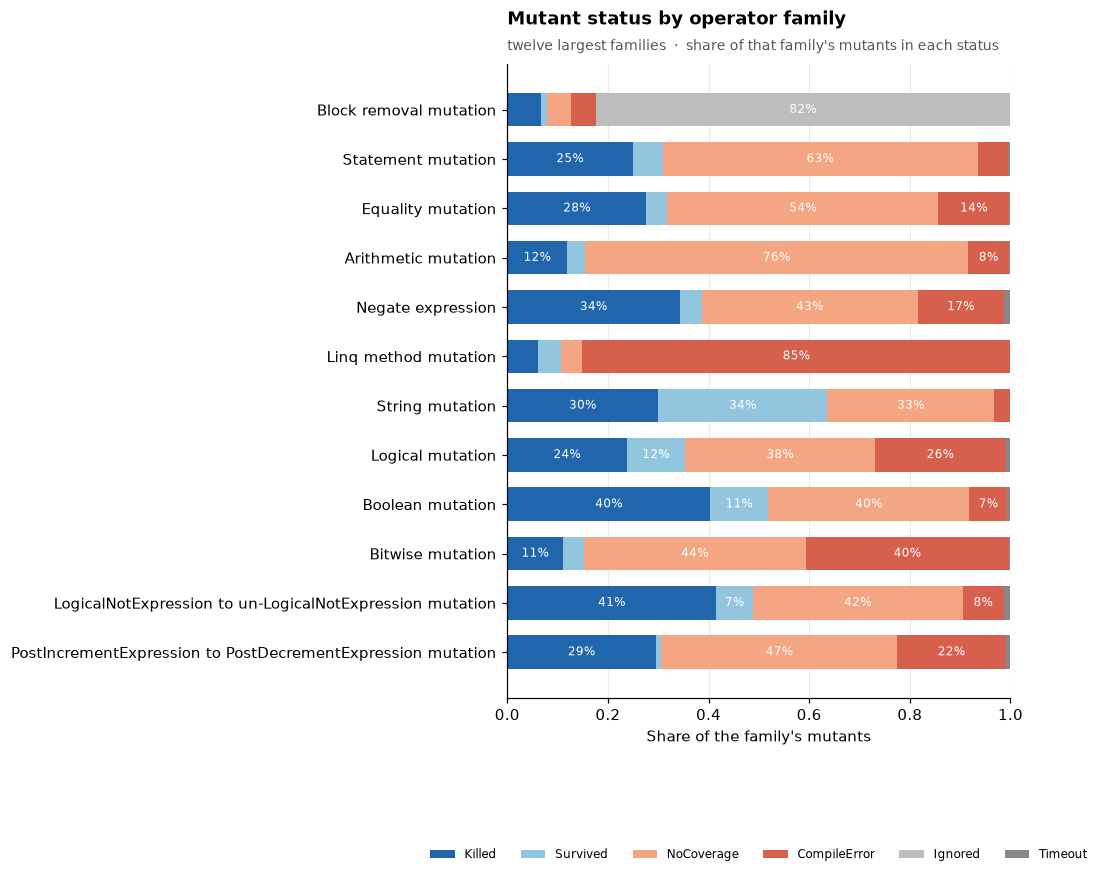

In [27]:
# Status composition per operator family, largest families first. Read down the
# NoCoverage column: an operator that mostly lands in untested code says more about
# where it fires than about the tests.
if not operators_base.empty:
    top_families = by_family.head(12).index
    shares = (
        by_family.loc[top_families, STATUS_ORDER]
        .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
        .iloc[::-1]
    )
    display(shares.round(3))
    msr_plots.stacked_share_bar(
        shares, "Mutant status by operator family",
        subtitle="twelve largest families  ·  share of that family's mutants in each status",
        xlabel="Share of the family's mutants",
        colors=["#2166ac", "#92c5de", "#f4a582", "#d6604d", "#bdbdbd", "#878787"],
    )
    plt.tight_layout()
    plt.show()

In [28]:
# Exact operator names, for the families that hide several distinct rewrites.
if not operators_base.empty:
    by_name = (
        operators_base.pivot_table(index="mutator_name", columns="status",
                                     values="mutants", aggfunc="sum", fill_value=0)
        .reindex(columns=STATUS_ORDER, fill_value=0)
    )
    by_name["total"] = by_name.sum(axis=1)
    scored = by_name["Killed"] + by_name["Survived"]
    by_name["kill_rate"] = (by_name["Killed"] / scored).where(scored > 0)
    print(f"{len(by_name)} distinct operators")
    display(by_name.sort_values("total", ascending=False).head(25))

60 distinct operators


status,Killed,Survived,NoCoverage,CompileError,Ignored,Timeout,total,kill_rate
mutator_name,,,,,,,,
Block removal mutation,402,67,280,298,4873,11,5931,0.8571
Statement mutation,1224,294,3079,300,0,22,4919,0.8063
Equality mutation,1321,201,2574,671,0,14,4781,0.8679
Arithmetic mutation,185,56,1187,127,0,5,1560,0.7676
Negate expression,464,59,582,232,0,18,1355,0.8872
String mutation,245,276,271,26,0,1,819,0.4702
Logical mutation,179,88,284,197,0,7,755,0.6704
Boolean mutation,297,84,295,55,0,5,736,0.7795
Bitwise mutation,64,24,256,234,0,2,580,0.7273


In [29]:
# Attribution: member_id is nullable, so Stryker can report a mutant TestMap
# cannot place on any entity.
display(attribution_summary("mutants_unattributed", "mutants"))
print("repositories ranked by unattributed mutant rate")
display(rank_unattributed("mutants_unattributed"))
print("members carrying no mutants")
display(entity_gap_summary("members_missing_mutants", "member"))
print("repositories ranked by members carrying no mutants")
display(rank_unattributed("members_missing_mutants"))

print("baseline report only: unattributed mutants by repository")
display(
    operators_base.groupby("repo_key")[["mutants", "unattributed"]].sum()
    .assign(rate=lambda d: d["unattributed"] / d["mutants"])
    .sort_values("rate", ascending=False)
)


,construct,observations,attributed,missing_attribution,attributed_pct
0,mutants,1004630,564700,439930,0.5621


repositories ranked by unattributed mutant rate


,repo_key,numerator,denominator,rate
0,cysharp/zstring@e2b86f7ad433,426990,710016,0.6014
1,dotnetcore/aspectcore-framework@d8fa5ca2d16c,12940,94797,0.1365


members carrying no mutants


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,member,10203,1853,8350,0.1816,4


repositories ranked by members carrying no mutants


,repo_key,numerator,denominator,rate
0,dotnetcore/aspectcore-framework@d8fa5ca2d16c,6105,6881,0.8872
1,alirezanet/gridify@2d6b9b3fe66f,1155,1398,0.8262
2,cysharp/zstring@e2b86f7ad433,480,821,0.5847
3,serilog/serilog-expressions@697c8fa89ec1,610,1103,0.553


baseline report only: unattributed mutants by repository


,mutants,unattributed,rate
repo_key,,,
cysharp/zstring@e2b86f7ad433,16512,9930,0.6014
dotnetcore/aspectcore-framework@d8fa5ca2d16c,5193,229,0.0441
serilog/serilog-expressions@697c8fa89ec1,2894,0,0


## Test Members And Execution

The test side of the corpus: how much of the mined code is test code, which
frameworks it uses, whether executed results attach to a test member, and how those
tests resolve and how long they take.

`test_results.method_id` is NOT NULL, so an unresolved test name is stored as **0**
rather than as a null. That makes this gap visible from the database — unlike the
coverage mapper, which drops unmatched entries entirely and leaves nothing to count.

Attribution is reported in both directions, because they answer different questions:
how many **results** failed to attach to a member, and how many **members** never
received a result.

In [30]:
# How much of the corpus is test code.
members_frame = entities[entities["entity_kind"] == "member"]
objects_frame = entities[entities["entity_kind"] == "object"]

test_shape = pd.DataFrame([
    {"entity": "members", "total": len(members_frame),
     "test": int(members_frame["is_test"].sum())},
    {"entity": "objects", "total": len(objects_frame),
     "test": int(objects_frame["is_test"].sum())},
]).assign(test_share=lambda d: d["test"] / d["total"],
          production=lambda d: d["total"] - d["test"])
display(test_shape)

print("test members per repository")
per_repo_tests = repositories[["repo_key", "members", "test_members"]].copy()
per_repo_tests["test_share"] = per_repo_tests["test_members"] / per_repo_tests["members"]
display(describe_numeric(per_repo_tests, ["test_members", "test_share"]))
display(iqr_table(per_repo_tests, ["test_members", "test_share"]))

print("members the experiment persisted (is_generated)")
display(
    members_frame.assign(generated_test=lambda d: (d["is_generated"] == 1) & (d["is_test"] == 1))
    .groupby("repo_key")
    .agg(members=("entity_id", "size"), generated=("is_generated", "sum"),
         generated_tests=("generated_test", "sum"))
)


,entity,total,test,test_share,production
0,members,10203,3928,0.385,6275
1,objects,2133,327,0.1533,1806


test members per repository


,column,count,missing,min,max,mean,median,std
0,test_members,4,0,133,"3,032",982,381.5,"1,379"
1,test_share,4,0,0.1206,0.4406,0.3033,0.3259,0.1447


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,test_members,4,191.5,381.5,"1,172",980.5,"-1,279","2,643",0,1,0.25
1,test_share,4,0.2229,0.3259,0.4063,0.1834,-0.0522,0.6814,0,0,0


members the experiment persisted (is_generated)


,members,generated,generated_tests
repo_key,,,
alirezanet/gridify@2d6b9b3fe66f,1398,10,10
cysharp/zstring@e2b86f7ad433,821,7,7
dotnetcore/aspectcore-framework@d8fa5ca2d16c,6881,15,15
serilog/serilog-expressions@697c8fa89ec1,1103,4,4


,test_classes,share,repositories
test_framework,,,
xUnit,305,0.9327,4
NUnit,22,0.06728,4


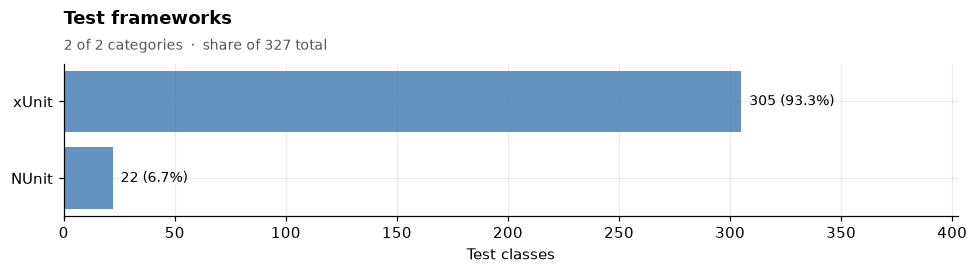

In [31]:
# Framework shares. Counted over test objects, since the framework is a property
# of the test class rather than of an individual test method.
test_objects = objects_frame[objects_frame["is_test"] == 1]
if not test_objects.empty:
    frameworks = (
        test_objects["test_framework"].fillna("(none recorded)")
        .value_counts().rename("test_classes").to_frame()
        .assign(share=lambda d: d["test_classes"] / d["test_classes"].sum(),
                repositories=lambda d: test_objects.groupby(
                    test_objects["test_framework"].fillna("(none recorded)")
                )["repo_key"].nunique().reindex(d.index))
    )
    display(frameworks)
    msr_plots.category_bar(frameworks["test_classes"],
                           "Test frameworks", "Test classes")
    plt.tight_layout()
    plt.show()

In [32]:
# Attribution: does an executed test attach to a test member?
display(attribution_summary("test_results_unattributed", "test_results"))
print("repositories ranked by unattributed test result rate")
display(rank_unattributed("test_results_unattributed"))

# The complement: test members the runner never reported a result for. These are
# different questions - a result with no member, versus a member with no result -
# and they do not have to agree.
print("test members carrying no test result")
display(entity_gap_summary("test_members_missing_results", "test member"))
print("repositories ranked by test members carrying no result")
display(rank_unattributed("test_members_missing_results"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,test_results,80044,77769,2275,0.9716


repositories ranked by unattributed test result rate


,repo_key,numerator,denominator,rate
0,alirezanet/gridify@2d6b9b3fe66f,816,17783,0.04589
1,serilog/serilog-expressions@697c8fa89ec1,724,20506,0.03531
2,dotnetcore/aspectcore-framework@d8fa5ca2d16c,670,35287,0.01899
3,cysharp/zstring@e2b86f7ad433,65,6468,0.01005


test members carrying no test result


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,test member,3928,3791,137,0.9651,4


repositories ranked by test members carrying no result


,repo_key,numerator,denominator,rate
0,serilog/serilog-expressions@697c8fa89ec1,22,133,0.1654
1,cysharp/zstring@e2b86f7ad433,27,211,0.128
2,alirezanet/gridify@2d6b9b3fe66f,34,552,0.06159
3,dotnetcore/aspectcore-framework@d8fa5ca2d16c,54,3032,0.01781


,results,share_of_all
outcome,,
Passed,8479,1


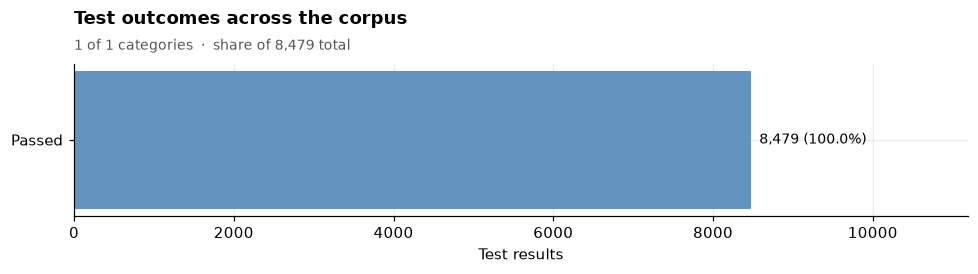

,column,count,missing,min,max,mean,median,std
0,results,4,0,147,"6,146","2,120","1,093","2,724"
1,pass_rate,4,0,1,1,1,1,0


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,results,4,732.8,"1,093","2,480","1,747","-1,888","5,101",0,1,0.25
1,pass_rate,4,1,1,1,0,1,1,0,0,0


In [33]:
# Outcome shares across every executed test.
if not test_results_base.empty:
    outcome_dist = (
        test_results_base["outcome"].value_counts().rename("results").to_frame()
        .assign(share_of_all=lambda d: d["results"] / d["results"].sum())
    )
    display(outcome_dist)
    msr_plots.category_bar(outcome_dist["results"],
                           "Test outcomes across the corpus", "Test results")
    plt.tight_layout()
    plt.show()

    # Per repository, so a handful of huge suites cannot set the corpus rate.
    per_repo_outcome = (
        test_results_base.assign(passed=lambda d: d["outcome"].eq("Passed"))
        .groupby("repo_key")["passed"].agg(results="size", passed="sum")
        .assign(pass_rate=lambda d: d["passed"] / d["results"])
        .reset_index()
    )
    display(describe_numeric(per_repo_outcome, ["results", "pass_rate"]))
    display(iqr_table(per_repo_outcome, ["results", "pass_rate"]))

# Scoped to the baseline test run; attempt runs re-execute the same suite.


,column,count,missing,min,max,mean,median,std
0,duration_seconds,8479,0,2.5e-06,3.289,0.02511,0.001619,0.1431


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,duration_seconds,8479,0.0005086,0.001619,0.007345,0.006836,-0.009745,0.0176,0,1285,0.1516


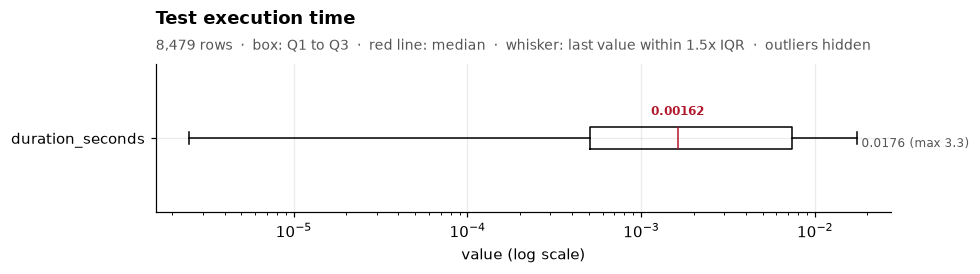

by outcome


,outcome,column,count,missing,min,max,mean,median,std
0,Passed,duration_seconds,8479,0,2.5e-06,3.289,0.02511,0.001619,0.1431


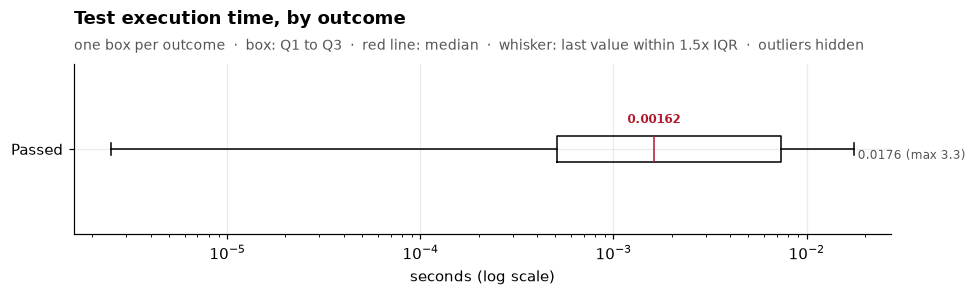

In [34]:
# Execution time. Durations are .NET TimeSpan strings converted to seconds; the
# distribution is heavy-tailed enough that the log axis is the readable one.
if not test_results_base.empty and test_results_base["duration_seconds"].notna().any():
    timed = test_results_base[test_results_base["duration_seconds"] > 0]
    display(describe_numeric(test_results_base, ["duration_seconds"]))
    display(iqr_table(test_results_base, ["duration_seconds"]))
    msr_plots.distribution_box(timed, ["duration_seconds"],
                               title="Test execution time")
    plt.tight_layout()
    plt.show()

    print("by outcome")
    display(describe_numeric(test_results_base, ["duration_seconds"], by="outcome"))
    msr_plots.grouped_box(timed, "duration_seconds", "outcome",
                          title="Test execution time, by outcome",
                          xlabel="seconds")
    plt.tight_layout()
    plt.show()

## Source To Test Mappings

Mappings come from Roslyn semantic traces, persisted with an evidence kind, a path
length and a chain of trace steps.

What this pass checks is shape, not correctness: that `(source_member_id,
test_member_id)` is unique, and that mappings point the right way.

The production-member denominator is scoped to **methods and constructors**.
Mapping evidence is direct method and constructor invocation, so a property or a
field can never carry a mapping — including them would put every property and field
in the denominator at a structural zero and make the rate describe the evidence
model rather than the data. The by-kind table below carries the counts.
`mappings_source_is_test_member` and `mappings_test_not_test_member` catch a source
that is itself a test method, or a test end that is not a test member. Whether a
mapping describes a test that genuinely exercises the member is a rater question,
not one the frames can answer.

In [35]:
# Both complements. A mapping has two ends, so "what has no mapping" is two
# questions: tests whose target the resolver never reached, and production code
# no test provably exercises.
print("members carrying no mapping")
display(pd.concat([
    entity_gap_summary("test_members_missing_mappings", "test member"),
    entity_gap_summary("production_members_missing_mappings", "production member"),
], ignore_index=True))

print("repositories ranked by test members carrying no mapping")
display(rank_unattributed("test_members_missing_mappings"))

# Attribution, asked the same way as for smells, mutants, and test results. Both
# endpoints are NOT NULL foreign keys, so a mapping the resolver could not
# attribute is never written at all: this row is 0 by construction and is
# evidence about the schema, not about the resolver. The resolver's misses are
# only visible from the entity side, in the two complements above.
print("mapping rows naming no entity")
display(attribution_summary("mappings_unattributed", "mappings"))

for check in ["mappings_duplicate_pair",
              "mappings_source_is_test_member", "mappings_test_not_test_member"]:
    print(check)
    display(check_by_repo(check, top_n=10))

members carrying no mapping


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,test member,3928,1328,2600,0.3381,4
1,production member,4148,322,3826,0.07763,4


repositories ranked by test members carrying no mapping


,repo_key,numerator,denominator,rate
0,cysharp/zstring@e2b86f7ad433,183,211,0.8673
1,dotnetcore/aspectcore-framework@d8fa5ca2d16c,2196,3032,0.7243
2,serilog/serilog-expressions@697c8fa89ec1,75,133,0.5639
3,alirezanet/gridify@2d6b9b3fe66f,146,552,0.2645


mapping rows naming no entity


...

,repo_key,check,numerator,denominator,rate
0,alirezanet/gridify@2d6b9b3fe66f,mappings_duplicate_pair,0,1809,0
1,cysharp/zstring@e2b86f7ad433,mappings_duplicate_pair,0,49,0
2,dotnetcore/aspectcore-framework@d8fa5ca2d16c,mappings_duplicate_pair,0,1713,0
3,serilog/serilog-expressions@697c8fa89ec1,mappings_duplicate_pair,0,289,0


mappings_source_is_test_member


,repo_key,check,numerator,denominator,rate
0,alirezanet/gridify@2d6b9b3fe66f,mappings_source_is_test_member,0,1809,0
1,cysharp/zstring@e2b86f7ad433,mappings_source_is_test_member,0,49,0
2,dotnetcore/aspectcore-framework@d8fa5ca2d16c,mappings_source_is_test_member,0,1713,0
3,serilog/serilog-expressions@697c8fa89ec1,mappings_source_is_test_member,0,289,0


mappings_test_not_test_member


,repo_key,check,numerator,denominator,rate
0,alirezanet/gridify@2d6b9b3fe66f,mappings_test_not_test_member,0,1809,0
1,cysharp/zstring@e2b86f7ad433,mappings_test_not_test_member,0,49,0
2,dotnetcore/aspectcore-framework@d8fa5ca2d16c,mappings_test_not_test_member,0,1713,0
3,serilog/serilog-expressions@697c8fa89ec1,mappings_test_not_test_member,0,289,0


,mappings,repos,mean_path_length
evidence_kind,,,
DirectMethodInvocation,2633,4,1
DirectConstructorInvocation,660,4,1
HelperMediatedPath,567,3,2.303


,column,count,missing,min,max,mean,median,std
0,path_length,3860,0,1,3,1.191,1,0.4939


,members,mapped,mapped_share
kind,,,
method,3720,287,0.07715
field,1113,0,0
property,1008,0,0
constructor,425,35,0.08235
operator,6,0,0
static_constructor,3,0,0


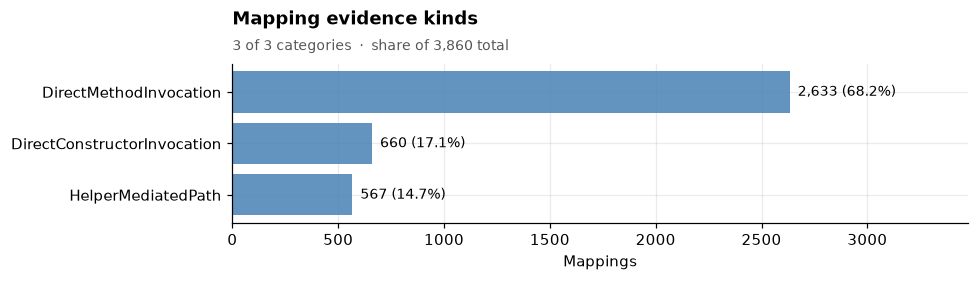

In [36]:
if not mappings.empty:
    display(
        mappings.groupby("evidence_kind")
        .agg(mappings=("observation_id", "size"),
             repos=("repo_key", "nunique"),
             mean_path_length=("path_length", "mean"))
        .sort_values("mappings", ascending=False)
    )
    display(describe_numeric(mappings, ["path_length"]))

    # Which member kinds ever receive a mapping, which is what sets the
    # denominator above.
    prod = entities[(entities["entity_kind"] == "member") & (entities["is_test"] == 0)
                    & (entities["repo_key"].isin(set(mappings["repo_key"])))]
    mapped_src = set(zip(mappings["repo_key"], mappings["source_member_id"].astype(int)))
    prod = prod.assign(has_mapping=[(r, e) in mapped_src
                                    for r, e in zip(prod["repo_key"], prod["entity_id"])])
    display(
        prod.groupby("kind")["has_mapping"]
        .agg(members="size", mapped="sum")
        .assign(mapped_share=lambda d: d["mapped"] / d["members"])
        .sort_values("members", ascending=False)
    )

    msr_plots.category_bar(mappings["evidence_kind"].value_counts(),
                           "Mapping evidence kinds", "Mappings")
    plt.tight_layout()
    plt.show()

In [37]:
# Mapping recall frame: production members with no mapping at all. This is the
# complement stratum - precision sampling cannot see it.
if not mappings.empty and not entities.empty:
    scoped = set(mappings["repo_key"])
    prod = entities[
        (entities["entity_kind"] == "member")
        & (entities["is_test"] == 0)
        & (entities["repo_key"].isin(scoped))
    ]
    mapped = set(zip(mappings["repo_key"], mappings["source_member_id"]))
    prod = prod.assign(has_mapping=[(r, e) in mapped for r, e in zip(prod["repo_key"], prod["entity_id"])])
    print(f"production members: {len(prod):,}  with a mapping: {int(prod['has_mapping'].sum()):,} "
          f"({prod['has_mapping'].mean():.1%})")
    display(
        prod.groupby("kind")["has_mapping"]
        .agg(members="size", mapped="sum")
        .assign(mapped_rate=lambda d: d["mapped"] / d["members"])
        .sort_values("members", ascending=False)
    )

production members: 6,275  with a mapping: 322 (5.1%)


,members,mapped,mapped_rate
kind,,,
method,3720,287,0.07715
field,1113,0,0
property,1008,0,0
constructor,425,35,0.08235
operator,6,0,0
static_constructor,3,0,0


## Pilot Against The MSR Corpus

A pilot repository that is also in the MSR validation corpus at the same commit has been
mined twice. The MSR run used an earlier TestMap build, so a difference is either a change
in the mining layer between the two builds or nondeterminism within one — never a property
of the repository. Either way the MSR validation figures describe the earlier build, and a
large difference means they do not transfer to the build the full evaluation will use. Mutation attribution is compared on the same terms:
the pilot baseline against the MSR run's single report.

In [38]:
msr_repos = load("repositories", MSR_FRAMES)
msr_checks = load("structural_checks", MSR_FRAMES)
both = repositories.merge(msr_repos, on="repo_key", suffixes=("_pilot", "_msr"))
print(f"{len(both)} of {len(repositories)} pilot repositories are in the MSR corpus at the same commit")

STATIC = ["files", "objects", "members", "test_members", "code_metrics", "test_smells", "mappings"]
if not both.empty:
    rows = []
    for row in both.itertuples():
        generated = int(getattr(row, "generated_members_pilot", 0) or 0)
        for column in STATIC:
            pilot = int(getattr(row, f"{column}_pilot"))
            msr = int(getattr(row, f"{column}_msr"))
            adjusted = pilot - generated if column == "members" else pilot
            rows.append({"repo_key": row.repo_key, "count": column, "pilot": pilot,
                         "pilot_minus_generated": adjusted, "msr": msr,
                         "difference": adjusted - msr})
    static_diff = pd.DataFrame(rows)
    display(static_diff)

    msr_unattributed = (
        msr_checks[(msr_checks["check"] == "mutants_unattributed")
                   & msr_checks["repo_key"].isin(both["repo_key"])]
        .set_index("repo_key")["rate"].rename("msr_unattributed_rate")
    )
    pilot_unattributed = (
        operators_base.groupby("repo_key")[["mutants", "unattributed"]].sum()
        .pipe(lambda d: d["unattributed"] / d["mutants"]).rename("pilot_baseline_unattributed_rate")
    )
    display(pd.concat([pilot_unattributed, msr_unattributed], axis=1, join="inner"))

4 of 4 pilot repositories are in the MSR corpus at the same commit


,repo_key,count,pilot,pilot_minus_generated,msr,difference
0,alirezanet/gridify@2d6b9b3fe66f,files,128,128,126,2
1,alirezanet/gridify@2d6b9b3fe66f,objects,211,211,208,3
2,alirezanet/gridify@2d6b9b3fe66f,members,1398,1388,1225,163
3,alirezanet/gridify@2d6b9b3fe66f,test_members,552,552,385,167
4,alirezanet/gridify@2d6b9b3fe66f,code_metrics,1587,1587,1431,156
5,alirezanet/gridify@2d6b9b3fe66f,test_smells,835,835,523,312
6,alirezanet/gridify@2d6b9b3fe66f,mappings,1809,1809,1660,149
7,cysharp/zstring@e2b86f7ad433,files,70,70,69,1
8,cysharp/zstring@e2b86f7ad433,objects,86,86,79,7
9,cysharp/zstring@e2b86f7ad433,members,821,814,661,153


,pilot_baseline_unattributed_rate,msr_unattributed_rate
repo_key,,
cysharp/zstring@e2b86f7ad433,0.6014,0.6014
dotnetcore/aspectcore-framework@d8fa5ca2d16c,0.0441,0.0441
serilog/serilog-expressions@697c8fa89ec1,0,0


In [39]:
# Identity-level comparison of test members. A test member the pilot holds and the MSR run
# of the same commit does not is either new detection or a test an attempt wrote into the
# workspace that the re-analysis then persisted. is_generated is meant to mark the latter,
# and TestMap-generated tests carry a GeneratedScenario name, so the two can be checked.
if not both.empty:
    ent_cols = ["repo_key", "entity_kind", "entity_id", "name", "kind", "is_test",
                "is_generated", "start_line", "file_id"]
    msr_entities = pd.read_csv(MSR_FRAMES / "msr_entities.csv", usecols=ent_cols, low_memory=False)
    msr_entities = msr_entities[msr_entities["repo_key"].isin(both["repo_key"])]
    msr_files = load("files", MSR_FRAMES)

    def test_members_with_path(ents: pd.DataFrame, file_frame: pd.DataFrame) -> pd.DataFrame:
        tests = ents[(ents["entity_kind"] == "member") & (ents["is_test"] == 1)].merge(
            file_frame[["repo_key", "file_id", "file_path"]], on=["repo_key", "file_id"], how="left")
        # Workspace roots differ between runs; compare on the last two path segments.
        tests["rel_path"] = (tests["file_path"].astype(str).str.replace("\\", "/", regex=False)
                             .str.split("/").str[-2:].str.join("/"))
        return tests

    pilot_tests = test_members_with_path(entities[entities["repo_key"].isin(both["repo_key"])], files)
    msr_tests = test_members_with_path(msr_entities, msr_files)
    msr_keys = set(zip(msr_tests["repo_key"], msr_tests["rel_path"], msr_tests["name"]))
    pilot_tests = pilot_tests.assign(
        in_msr=[k in msr_keys for k in zip(pilot_tests["repo_key"], pilot_tests["rel_path"],
                                           pilot_tests["name"])],
        generated_name=pilot_tests["name"].str.contains("GeneratedScenario", regex=False),
    )
    pilot_tests["generated_name_unflagged"] = pilot_tests["generated_name"] & (pilot_tests["is_generated"] == 0)
    pilot_tests["new_other"] = ~pilot_tests["in_msr"] & ~pilot_tests["generated_name"]
    display(pilot_tests.groupby("repo_key").agg(
        pilot_test_members=("entity_id", "size"),
        not_in_msr=("in_msr", lambda s: int((~s).sum())),
        flagged_generated=("is_generated", "sum"),
        generated_name_unflagged=("generated_name_unflagged", "sum"),
        new_other=("new_other", "sum"),
    ).join(msr_tests.groupby("repo_key").size().rename("msr_test_members")))

    members_only = entities[entities["entity_kind"] == "member"]
    duplicated = members_only.duplicated(["repo_key", "file_id", "name", "kind", "start_line"])
    print("duplicate member rows (same file, name, kind and start line):",
          duplicated.groupby(members_only["repo_key"]).sum().to_dict())

,pilot_test_members,not_in_msr,flagged_generated,generated_name_unflagged,new_other,msr_test_members
repo_key,,,,,,
alirezanet/gridify@2d6b9b3fe66f,552,148,10,0,140,385
cysharp/zstring@e2b86f7ad433,211,147,7,0,140,63
dotnetcore/aspectcore-framework@d8fa5ca2d16c,3032,256,15,0,243,2770
serilog/serilog-expressions@697c8fa89ec1,133,60,4,0,56,59


duplicate member rows (same file, name, kind and start line): {'alirezanet/gridify@2d6b9b3fe66f': 7, 'cysharp/zstring@e2b86f7ad433': 7, 'dotnetcore/aspectcore-framework@d8fa5ca2d16c': 10, 'serilog/serilog-expressions@697c8fa89ec1': 15}


## Repository Characteristics

Where the pilot repositories sit in the population they were drawn from: the repositories
with tests detected (the screening manifest), as in `00_msr_validation`. The percentile rank
is the share of screened repositories at or below the pilot value, so a rank near 1 means the
pilot repository is among the largest on that measure.

In [40]:
# The file is tab-delimited and is being relabelled .tsv; take whichever exists.
import json
import re

REPO_LIST_DIR = Path("../../Replication/LicenseFilterRepo")
REPO_LIST = next(
    (REPO_LIST_DIR / f"licenseFilteredRepoList{ext}"
     for ext in (".tsv", ".csv")
     if (REPO_LIST_DIR / f"licenseFilteredRepoList{ext}").exists()),
    REPO_LIST_DIR / "licenseFilteredRepoList.tsv",
)
REFERENCE_DATE = pd.Timestamp("2026-07-16")   # licenseFiltered.yaml generated_at_utc

# Source column -> reported name. Explicit rather than fuzzy-matched: the schema
# is known, and a silent mismatch would drop a column from the table unnoticed.
REPO_COLUMNS = {
    "commits": "commits",
    "contributors": "contributors",
    "totalPullRequests": "pull_requests",
    "totalIssues": "issues",
    "size": "size_kb",
    "codeLines": "code_lines",
    "stargazers": "stars",
    "forks": "forks",
    "releases": "releases",
    "branches": "branches",
}

REPO_STAT_COLS = list(REPO_COLUMNS.values()) + ["csharp_lines", "age_years"]

if not REPO_LIST.exists():
    print(f"[missing] {REPO_LIST}")
    repo_stats = pd.DataFrame()
else:
    # The delimiter is sniffed from the header rather than assumed. This file has
    # been tab-delimited under a .csv extension; several columns carry embedded
    # JSON, so guessing wrong fails the parse outright instead of misreading.
    header = REPO_LIST.open(encoding="utf-8", errors="replace").readline()
    delimiter = "	" if header.count("	") > header.count(",") else ","
    print(f"source: {REPO_LIST.name}  ·  "
          f"delimiter: {'tab' if delimiter == chr(9) else 'comma'}")
    raw = pd.read_csv(REPO_LIST, sep=delimiter, low_memory=False)
    missing_cols = sorted(set(REPO_COLUMNS) - set(raw.columns))
    if missing_cols:
        print(f"[warn] columns not in the source list: {missing_cols}")

    repo_stats = raw.rename(columns=REPO_COLUMNS)
    created = pd.to_datetime(raw["createdAt"], errors="coerce")
    repo_stats["age_years"] = (REFERENCE_DATE - created).dt.days / 365.25
    repo_stats["repository"] = raw["name"].str.lower()

    # code_lines counts every language in the repository. Some entries are data
    # repositories with a small C# tool attached - one has 35M lines of which
    # 3,964 are C# - so the C# figure is pulled out of the per-language metrics
    # and used wherever "size" means "how much C# there is to analyse".
    def _csharp_lines(value) -> float:
        try:
            return sum(entry.get("codeLines", 0) for entry in json.loads(value)
                       if entry.get("language") == "C#")
        except (TypeError, ValueError):
            return float("nan")

    repo_stats["csharp_lines"] = raw["metrics"].map(_csharp_lines)
    share = repo_stats["csharp_lines"] / repo_stats["code_lines"]
    print(f"C# share of all code lines: median {share.median():.0%}  ·  "
          f"{int((share < 0.10).sum()):,} repositories are under 10% C#")

    print(f"{len(repo_stats):,} repositories in the full source list")

# The population that actually entered the pipeline is the screening manifest:
# repositories where a project check detected tests. Everything downstream is
# compared against that, not against the full list.
SCREENED_MANIFEST = Path(
    "../../Replication/LicenseFilterCheckProjects"
    "/licenseFiltered-project-check-tests-detected-e5cb6c9c8a53.yaml"
)

if not repo_stats.empty and SCREENED_MANIFEST.exists():
    screened_names = {
        name.lower() for name in re.findall(
            r"^ *repository: *(\S+)",
            SCREENED_MANIFEST.read_text(encoding="utf-8"), re.M)
    }
    screened = repo_stats[repo_stats["repository"].isin(screened_names)]
    print(f"{len(screened_names):,} targets in the tests-detected manifest  ·  "
          f"{len(screened):,} matched to the source list")
    screened_raw = raw[raw["name"].str.lower().isin(screened_names)]
    def _flag(column: str) -> int:
        return int(screened_raw[column].astype(str).str.upper().eq("TRUE").sum())
    print(f"forks: {_flag('isFork'):,}   archived: {_flag('isArchived'):,}")
else:
    screened = repo_stats
    if not repo_stats.empty:
        print(f"[warn] {SCREENED_MANIFEST} not found; falling back to the full list")

source: licenseFilteredRepoList.tsv  ·  delimiter: tab
C# share of all code lines: median 61%  ·  97 repositories are under 10% C#
1,525 repositories in the full source list
1,295 targets in the tests-detected manifest  ·  1,295 matched to the source list
forks: 24   archived: 8


In [41]:
if not screened.empty:
    pilot_names = set((repositories["owner"] + "/" + repositories["repo_name"]).str.lower())
    pilot_stats = screened[screened["repository"].isin(pilot_names)].set_index("repository")
    missing = sorted(pilot_names - set(pilot_stats.index))
    if missing:
        print(f"[warn] pilot repositories not in the screened list: {missing}")
    display(pilot_stats[REPO_STAT_COLS])
    ranks = pd.DataFrame(
        {c: [(screened[c] <= v).mean() for v in pilot_stats[c]] for c in REPO_STAT_COLS},
        index=pilot_stats.index,
    )
    print("percentile rank within the tests-detected population")
    display(ranks.round(2))

,commits,contributors,pull_requests,issues,size_kb,code_lines,stars,forks,releases,branches,csharp_lines,age_years
repository,,,,,,,,,,,,
alirezanet/gridify,733,24,140,127,2935,21963,1130,81,84,11,10885,6.037
dotnetcore/aspectcore-framework,1026,22,172,197,2840,65894,1765,330,22,21,60695,9.982
cysharp/zstring,268,22,81,64,859,27136,2768,187,18,3,26125,6.445
serilog/serilog-expressions,213,13,68,68,598,8366,217,21,14,2,7552,5.875


percentile rank within the tests-detected population


,commits,contributors,pull_requests,issues,size_kb,code_lines,stars,forks,releases,branches,csharp_lines,age_years
repository,,,,,,,,,,,,
alirezanet/gridify,0.36,0.43,0.25,0.38,0.2,0.21,0.69,0.47,0.79,0.44,0.19,0.33
dotnetcore/aspectcore-framework,0.46,0.39,0.31,0.51,0.19,0.51,0.77,0.79,0.41,0.63,0.68,0.73
cysharp/zstring,0.04,0.39,0.13,0.22,0.04,0.26,0.85,0.68,0.37,0.13,0.44,0.38
serilog/serilog-expressions,0,0.14,0.1,0.23,0.02,0.05,0.38,0.16,0.32,0.07,0.11,0.31


## What This Pass Decides

The pilot ran end to end: four targets, all completed, every construct present in every
database. The findings below are the ones to settle before the full evaluation run. Each
comes from a table above.

**Fix before the full run**

1. **Agentic attempts contaminate the baseline project.** Tests an agentic tool wrote into
   the workspace are persisted as ordinary members of the analysed project, and nothing
   marks them: TestMap's own `*_GeneratedScenario_*` tests are flagged `is_generated`, the
   tool-written ones are not. The pilot-against-MSR table counts them — the `new_other`
   column — and the source confirms what they are: at the pinned commit zstring's
   `JoinTest.cs` holds 7 tests, the pilot database holds 154 test members in it, and
   serilog's `ConstantExpressionTests.cs` does not exist in the repository at all. The
   workspaces are clean again, so the files were reset after the attempts but their members
   stayed. Static constructs (members, metrics, smells, mappings) read from a
   post-experiment database therefore describe the repository *plus* its attempts. The
   duplicate member rows are the same failure seen from the other side: one test method
   under several member ids, which is what leaves the two remaining evaluation-audit errors
   pointing at a member id the generated-test row no longer carries.
2. **Attempt coverage runs a narrower scope than the baseline.** For gridify and aspectcore
   the attempt reports offer a small fraction of the baseline's raw members. Coverage
   deltas between an attempt and the baseline compare different assembly sets unless the
   delta is taken on the targeted member only.
3. **`HasMutationScore` and the mutation tables disagree for gridify.** The validation flag
   is right about the repository baseline, which produced no solution-scope report, but the
   database holds attempt-level mutation for it. Any consumer that trusts one and not the
   other will treat gridify inconsistently.
4. **`is_baseline` is overloaded.** It marks both the repository baseline and the tool
   lane's per-attempt targeted baselines; only `scope_kind` separates them. Worth a
   dedicated column or an explicit report kind before more consumers rely on it.

**Healthy, or already fixed**

- Coverage counts are persisted (`coverage_counts_missing_with_rate` reads zero), and
  unplaced coverage entries are persisted with a status and reason, so coverage attribution
  is measured rather than inferred. Most unplaced entries are out-of-project; the in-project
  miss rate is the figure to watch, and zstring is the outlier.
- Mutation attribution reproduces the MSR run exactly on the shared commits, so the
  unattributed-mutant rate is deterministic — and zstring's is still high, so the MSR bug
  it points at is still open.
- No defect-severity check fires beyond the one-line containment boundary cases already
  known from the MSR pass.

**What it means for the MSR validation**

The MSR corpus was mined by an earlier build. On the shared commits the static counts
differ, and the difference is dominated by attempt contamination rather than by a change
in detection, so the MSR figures stand for a clean single-pass database. They do not
transfer to databases that have been through an experiment until item 1 is fixed.